# Chapter 4.3: Sampling Depth and Claim Boundaries

This tutorial isolates the Chapter 4 sampling-depth, WFR-FM sensitivity, stochastic bridge, and claim-boundary audit experiments. It is designed to be read and run from top to bottom without depending on variables from another notebook.

By the end, the notebook has:
- quantified how EB snapshot sampling depth affects normalized state proportions and OT-derived growth proxy diagnostics;
- loaded the precomputed internal WFR-FM sampling-depth sensitivity artifacts, preserving the full-run artifact checks;
- shown a synthetic stochastic bridge as an interpretation boundary rather than EB growth/death evidence;
- written a table-only prior-boundary audit that records which biological priors require external evidence before becoming claims.

The prior-boundary component is a table audit, not a real-data prior experiment. The final manifest section verifies the paper-facing figures, tables, JSON summaries, run config, and split-specific manifest for this notebook.


## 0. Setup

This section makes the notebook independently runnable. It imports dependencies, resolves project paths, selects the device, fixes random seeds, creates output/cache directories, configures plotting, and exposes environment-variable overrides for smoke tests or controlled reruns.

Keep the defaults below as the chapter defaults: figures go to `figures/ch04`, tables and JSON summaries go to `outputs/ch04`, and intermediate caches go to `outputs/ch04/cache` unless `CH04_SMOKE_MODE=1` is set.


The setup is split into four runnable checks: dependency imports and paths, project-local imports, run controls, then output locations and plotting defaults.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch04")

from pathlib import Path
import sys
import json
import math
import time
import random
import hashlib
import warnings
from dataclasses import dataclass
from typing import Callable, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

try:
    import torch
    from torch import nn
except Exception as exc:
    raise ImportError("Chapter 4 experiments require PyTorch.") from exc

try:
    import anndata as ad
except Exception:
    ad = None

from scipy import sparse
from scipy.sparse.csgraph import shortest_path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:

from src.models import VelocityMLP as ProjectVelocityMLP, count_parameters
from src.losses import cfm_batch, cfm_loss_from_pairs
from src.train import train_cfm_steps
from src.sampling import euler_sample
from src.samplers import CouplingPairSampler as SrcCouplingPairSampler
from src.ot import independent_coupling, coupling_diagnostics
from src.metrics import (
    endpoint_metrics,
    fate_mass_error,
    coupling_l1_distance,
    normalized_cost_matrix,
    distribution_readout_metrics,
)
from src.representations import (
    fit_pca_state_space,
    pca_inverse_transform,
    program_index_dict,
    readout_program_scores_from_matrix,
    standardize_train_space,
)


In [3]:
SEEDS = [42, 43, 44]
DEFAULT_SEED = 42
SOURCE_TIME = "1"
TARGET_TIME = "2"
TRAINING_STEPS = int(os.environ.get("CH04_TRAINING_STEPS", "1500"))
BATCH_SIZE = int(os.environ.get("CH04_BATCH_SIZE", "256"))
DEFAULT_NFE = int(os.environ.get("CH04_DEFAULT_NFE", "64"))
NFE_GRID = [2, 4, 8, 16, 32, 64]
SINKHORN_EPSILON = float(os.environ.get("CH04_SINKHORN_EPSILON", "0.05"))
EPSILON_GRID = [0.01, 0.02, 0.05, 0.1, 0.5]
BOOTSTRAP_REPEATS = int(os.environ.get("CH04_BOOTSTRAP_REPEATS", "50"))
EB_MAX_CELLS_PER_TIME = os.environ.get("CH04_EB_MAX_CELLS_PER_TIME", "")
EB_MAX_CELLS_PER_TIME = None if EB_MAX_CELLS_PER_TIME == "" else int(EB_MAX_CELLS_PER_TIME)
TOY_TRAINING_STEPS = int(os.environ.get("CH04_TOY_TRAINING_STEPS", str(TRAINING_STEPS)))
SMOKE_MODE = os.environ.get("CH04_SMOKE_MODE", "0") == "1"
if SMOKE_MODE:
    TRAINING_STEPS = min(TRAINING_STEPS, 20)
    TOY_TRAINING_STEPS = min(TOY_TRAINING_STEPS, 20)
    BATCH_SIZE = min(BATCH_SIZE, 64)
    DEFAULT_NFE = min(DEFAULT_NFE, 8)
    NFE_GRID = [2, 4, 8]
    BOOTSTRAP_REPEATS = min(BOOTSTRAP_REPEATS, 3)
    EB_MAX_CELLS_PER_TIME = 120 if EB_MAX_CELLS_PER_TIME is None else min(EB_MAX_CELLS_PER_TIME, 120)


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = PROJECT_ROOT / "data"
EB_PATH = DATA_DIR / "trajectorynet_eb" / "eb_velocity_v5.npz"
TOY_DIR = DATA_DIR / "toy_branching_snapshots"
TOY_CSV_PATH = TOY_DIR / "observed_2d_snapshots.csv"
TOY_H5AD_PATH = TOY_DIR / "branching_toy_pseudocounts.h5ad"

FIG_DIR = PROJECT_ROOT /  "figures" / "ch04"
OUT_DIR = PROJECT_ROOT /  "outputs" / "ch04"
if SMOKE_MODE:
    FIG_DIR = FIG_DIR / "smoke"
    OUT_DIR = OUT_DIR / "smoke"
CACHE_DIR = OUT_DIR / "cache"
FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "ch04" / "new3"
for path in [FIG_DIR, OUT_DIR, CACHE_DIR, FINAL_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 320,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

PALETTE = {
    "source": "#4C78A8",
    "target": "#F58518",
    "random": "#8E8E8E",
    "ot": "#008A7A",
    "reflow1": "#5369A6",
    "reflow2": "#B279A2",
    "rare": "#D95F02",
    "major": "#2C7FB8",
    "program": "#54A24B",
    "diagnostic": "#E45756",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Training steps: {TRAINING_STEPS}; batch size: {BATCH_SIZE}; default NFE: {DEFAULT_NFE}")
print(f"Smoke mode: {SMOKE_MODE}")

Project root: /home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology
Device: cuda
Training steps: 1500; batch size: 256; default NFE: 64
Smoke mode: False


In [5]:
from src.utils import set_seed as _set_seed


def set_seed(seed: int = DEFAULT_SEED) -> None:
    _set_seed(seed)


from src.artifacts import json_ready, load_json, save_json

from src.artifacts import load_npz, load_pt as _load_pt, save_csv, save_npz, save_pt


def load_pt(path: str | Path, map_location=None):
    return _load_pt(path, map_location=map_location or DEVICE)


In [6]:
def save_figure(fig, filename: str, close: bool = True) -> Path:
    path = FIG_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return path


def save_pub_figure(fig, stem: str, close: bool = True) -> list[Path]:
    """Save one final small figure as PNG, PDF, and SVG."""
    FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)
    try:
        fig.tight_layout()
    except Exception:
        pass
    paths = []
    for ext in ("png", "pdf", "svg"):
        path = FINAL_FIG_DIR / f"{stem}.{ext}"
        save_kwargs = {"bbox_inches": "tight", "pad_inches": 0.06}
        if ext == "png":
            save_kwargs["dpi"] = 420
        fig.savefig(path, **save_kwargs)
        paths.append(path)
    if close:
        plt.close(fig)
    return paths


def display_saved_figure(filename: str | Path) -> None:
    path = Path(filename)
    if not path.is_absolute():
        path = FIG_DIR / path
    display(Image(filename=str(path)))


def display_final_png(stem: str) -> None:
    display(Image(filename=str(FINAL_FIG_DIR / f"{stem}.png")))


from src.artifacts import remember_source as _remember_source
from src.artifacts import resolve_required_artifact as _resolve_required_artifact
from src.artifacts import safe_relpath as _safe_relpath


def safe_relpath(path: str | Path, root: Path = PROJECT_ROOT) -> str:
    return _safe_relpath(path, root=root)


def resolve_required_artifact(filename: str, preferred_dirs: list[Path] | None = None) -> Path:
    """Resolve a required source artifact without fabricating missing values."""
    return _resolve_required_artifact(filename, preferred_dirs=preferred_dirs or [], search_root=PROJECT_ROOT)


FINAL_SOURCE_PATHS: dict[str, str] = {}


def remember_source(name: str, path: str | Path) -> Path:
    return _remember_source(FINAL_SOURCE_PATHS, name, path, root=PROJECT_ROOT)


from src.artifacts import artifact_exists, as_float32, ensure_finite, sample_rows as _sample_rows, stable_hash, to_tensor as _to_tensor


def sample_rows(n: int, max_n: int | None, seed: int = DEFAULT_SEED) -> np.ndarray:
    return _sample_rows(n, max_n, seed)


def to_tensor(x, device: torch.device = DEVICE):
    return _to_tensor(x, device)


## 1. Shared Utilities

The utility cells define the shared tutorial machinery used by the EB and toy sections: artifact writers, model wrappers, training/loading helpers, Sinkhorn diagnostics, rollout metrics, and plotting helpers.

The intent is auditability. The key CFM/Sinkhorn/rollout/metric logic stays visible in the notebook, while tested primitives from `src` are reused where available.


The next helper cells keep the scientific machinery readable: model/training wrappers first, then metric diagnostics, then coupling-overlap summaries.

In [7]:
class VelocityMLP(ProjectVelocityMLP):
    """Chapter 4 VelocityMLP wrapper with requested defaults.

    The underlying implementation is imported from `src.models`, but the
    requested architecture is fixed here: hidden=128 and layers=4.
    """
    def __init__(self, input_dim: int, hidden: int = 128, layers: int = 4):
        super().__init__(x_dim=int(input_dim), hidden_dim=int(hidden), hidden_layers=int(layers))


from src.flow_runtime import make_time_batch as _make_time_batch


def make_time_batch(batch_size: int, device: torch.device = DEVICE) -> torch.Tensor:
    return _make_time_batch(batch_size, device)


from src.ot import compute_cost_matrix, sample_independent_pairs as _sample_independent_pairs
from src.ot import sample_from_plan as _sample_from_plan, sinkhorn_plan as _sinkhorn_plan


def sample_independent_pairs(X0, X1, n_pairs: int, seed: int = DEFAULT_SEED):
    return _sample_independent_pairs(X0, X1, n_pairs=n_pairs, seed=seed)


def sinkhorn_plan(C, epsilon: float = SINKHORN_EPSILON, return_info: bool = False):
    return _sinkhorn_plan(C, epsilon=epsilon, return_info=return_info)


def sample_from_plan(pi, n_pairs: int, seed: int = DEFAULT_SEED):
    return _sample_from_plan(pi, n_pairs=n_pairs, seed=seed)


class PlanPairSampler:
    """Notebook-local thin wrapper around `src.samplers.CouplingPairSampler`."""
    def __init__(self, X0, X1, pi=None, seed: int = DEFAULT_SEED, labels0=None, labels1=None):
        self.X0 = as_float32(X0)
        self.X1 = as_float32(X1)
        if pi is None:
            pi = independent_coupling(len(self.X0), len(self.X1))
        self.pi = np.asarray(pi, dtype=float)
        self.src_sampler = SrcCouplingPairSampler(self.X0, self.X1, self.pi, seed=seed, labels0=labels0, labels1=labels1)

    def sample(self, batch_size: int = BATCH_SIZE):
        return self.src_sampler.sample(int(batch_size))


from src.flow_runtime import train_cfm as _train_cfm


def train_cfm(
    model,
    pair_sampler,
    steps: int = TRAINING_STEPS,
    batch_size: int = BATCH_SIZE,
    lr: float = 1e-3,
    device: torch.device = DEVICE,
    seed: int = DEFAULT_SEED,
    log_every: int = 250,
):
    kwargs = dict(steps=steps, batch_size=batch_size, lr=lr, device=device, seed=seed, log_every=log_every)
    return _train_cfm(model, pair_sampler, **kwargs)


Rollout wrappers are separate because they are used later for endpoint and path diagnostics after training or loading a model.

In [8]:
from src.flow_runtime import rollout_euler as _rollout_euler, trajectory_rollout as _trajectory_rollout


@torch.no_grad()
def rollout_euler(model, x0, nfe: int = DEFAULT_NFE, device: torch.device = DEVICE):
    return _rollout_euler(model, x0, nfe=nfe, device=device)


@torch.no_grad()
def trajectory_rollout(model, x0, nfe: int = DEFAULT_NFE, return_path: bool = True, device: torch.device = DEVICE):
    return _trajectory_rollout(model, x0, nfe=nfe, return_path=return_path, device=device)


In [9]:
from src.metrics import mmd_rbf, off_manifold_knn, path_energy, path_length, straightness
from src.metrics import straightness_action_S, tortuosity_straightness
from src.metrics import sliced_w2 as _sliced_w2


def sliced_w2(X, Y, n_projections: int = 128, seed: int = DEFAULT_SEED):
    return _sliced_w2(X, Y, n_projections=n_projections, seed=seed)

from src.flow_runtime import coarse_step_error as _coarse_step_error


def coarse_step_error(model, x0, nfe_coarse: int = 4, nfe_fine: int = 64):
    return _coarse_step_error(model, x0, nfe_coarse=nfe_coarse, nfe_fine=nfe_fine, device=DEVICE)


In [10]:
from src.metrics import coupling_topk_overlap, effective_support, plan_entropy, topk_nn_overlap
from src.metrics import evaluate_endpoint as _evaluate_endpoint


def evaluate_endpoint(pred, target, seed: int = DEFAULT_SEED):
    return _evaluate_endpoint(pred, target, seed=seed)

In [11]:
def plot_phate_pairs(X0_phate, X1_phate, idx0, idx1, title: str, max_lines: int = 120, seed: int = DEFAULT_SEED, values=None):
    return plot_pair_panels(
        X0_phate,
        X1_phate,
        [{"title": title, "idx0": idx0, "idx1": idx1, "values": values, "seed": seed}],
        filename="_temporary_pair_panel.png",
        title=title,
    )


def plot_pair_panels(X0_phate, X1_phate, panels, filename: str, title: str, value_label: str = "PC-20 chord length"):
    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 4.2), squeeze=False)
    axes_flat = axes[0]
    all_values = []
    for panel in panels:
        if panel.get("values") is not None:
            all_values.append(np.asarray(panel["values"], dtype=float))
    norm = None
    if all_values:
        finite = np.concatenate([v[np.isfinite(v)] for v in all_values if np.any(np.isfinite(v))])
        norm = Normalize(vmin=float(finite.min()), vmax=float(finite.max())) if finite.size else None
    for ax, panel in zip(axes_flat, panels):
        idx0, idx1 = panel["idx0"], panel["idx1"]
        ax.scatter(X0_phate[:, 0], X0_phate[:, 1], s=8, color=PALETTE["source"], alpha=0.20, linewidths=0)
        ax.scatter(X1_phate[:, 0], X1_phate[:, 1], s=8, color=PALETTE["target"], alpha=0.20, linewidths=0)
        keep = sample_rows(len(idx0), min(panel.get("max_lines", 100), len(idx0)), seed=panel.get("seed", DEFAULT_SEED))
        segments = np.stack([X0_phate[idx0[keep]], X1_phate[idx1[keep]]], axis=1)
        values = panel.get("values")
        if values is not None and norm is not None:
            lc = LineCollection(segments, cmap="viridis", norm=norm, linewidths=0.8, alpha=0.55)
            lc.set_array(np.asarray(values, dtype=float)[keep])
            ax.add_collection(lc)
        else:
            lc = LineCollection(segments, colors=panel.get("color", "0.45"), linewidths=0.7, alpha=0.25)
            ax.add_collection(lc)
        ax.set_title(panel["title"])
        ax.set_xlabel("PHATE 1")
        ax.set_ylabel("PHATE 2")
    if norm is not None:
        fig.colorbar(ScalarMappable(norm=norm, cmap="viridis"), ax=list(axes_flat), fraction=0.035, pad=0.02, label=value_label)
    fig.suptitle(title, y=1.02)
    return save_figure(fig, filename)



In [12]:
def add_local_arrows(ax, projected_traj, observed_phate, color, max_arrows: int = 28, seed: int = DEFAULT_SEED):
    """Draw local average arrows only for trajectory points close to observed PHATE neighborhoods."""
    projected_traj = np.asarray(projected_traj, dtype=float)
    observed_phate = np.asarray(observed_phate, dtype=float)
    if projected_traj.shape[0] < 3 or projected_traj.shape[-1] != 2:
        return
    mid_step = projected_traj.shape[0] // 2
    anchors = projected_traj[mid_step]
    deltas = projected_traj[min(mid_step + 1, projected_traj.shape[0] - 1)] - projected_traj[max(mid_step - 1, 0)]
    nn_obs = NearestNeighbors(n_neighbors=min(15, len(observed_phate))).fit(observed_phate)
    obs_r = nn_obs.kneighbors(observed_phate, return_distance=True)[0][:, -1]
    dist = nn_obs.kneighbors(anchors, return_distance=True)[0][:, 0]
    threshold = float(np.quantile(obs_r, 0.75))
    valid = np.flatnonzero(dist <= threshold)
    if valid.size == 0:
        return
    keep = sample_rows(len(valid), min(max_arrows, len(valid)), seed=seed)
    valid = valid[keep]
    ax.quiver(
        anchors[valid, 0], anchors[valid, 1], deltas[valid, 0], deltas[valid, 1],
        angles="xy", scale_units="xy", scale=1.0, width=0.004, color=color, alpha=0.75,
    )


def plot_projected_trajectories(paths, X0_phate, X1_phate, pc_to_phate, filename: str, title: str, max_lines: int = 45, local_arrows: bool = True):
    n = len(paths)
    fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 4.2), squeeze=False)
    observed_phate = np.vstack([X0_phate, X1_phate])
    for ax, (name, traj) in zip(axes[0], paths.items()):
        ax.scatter(X0_phate[:, 0], X0_phate[:, 1], s=8, color=PALETTE["source"], alpha=0.18, linewidths=0)
        ax.scatter(X1_phate[:, 0], X1_phate[:, 1], s=8, color=PALETTE["target"], alpha=0.16, linewidths=0)
        keep = sample_rows(traj.shape[1], min(max_lines, traj.shape[1]), seed=DEFAULT_SEED)
        selected = np.asarray(traj[:, keep, :], dtype=np.float32)
        flat = selected.reshape(-1, selected.shape[-1])
        ph = pc_to_phate(flat).reshape(selected.shape[0], selected.shape[1], 2)
        color = PALETTE.get(name, "0.35")
        for j in range(ph.shape[1]):
            ax.plot(ph[:, j, 0], ph[:, j, 1], color=color, alpha=0.55, linewidth=1.0)
        if local_arrows:
            add_local_arrows(ax, ph, observed_phate, color=color, seed=DEFAULT_SEED + 7)
        ax.set_title(name.replace("_", " "))
        ax.set_xlabel("PHATE 1 (display only)")
        ax.set_ylabel("PHATE 2 (display only)")
    fig.suptitle(title, y=1.02)
    return save_figure(fig, filename)


def plot_metric_lines(table, x: str, y: str, hue: str, filename: str, title: str):
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    for name, group in table.groupby(hue):
        group = group.sort_values(x)
        ax.plot(group[x], group[y], marker="o", linewidth=1.5, label=str(name).replace("_", " "))
    ax.set_xscale("log", base=2 if set(table[x]).issubset(set(NFE_GRID)) else 10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.legend(frameon=False)
    return save_figure(fig, filename)


def plot_heatmap(matrix, title: str, filename: str, max_size: int = 120, cmap: str = "viridis"):
    M = np.asarray(matrix)
    rows = sample_rows(M.shape[0], min(max_size, M.shape[0]), seed=DEFAULT_SEED)
    cols = sample_rows(M.shape[1], min(max_size, M.shape[1]), seed=DEFAULT_SEED + 1)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(M[np.ix_(rows, cols)], aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("target subset")
    ax.set_ylabel("source subset")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return save_figure(fig, filename)


def plot_table_image(frame: pd.DataFrame, filename: str, title: str, max_rows: int = 12):
    shown = frame.head(max_rows).copy()
    fig, ax = plt.subplots(figsize=(min(14, 1.5 + 1.4 * shown.shape[1]), 0.8 + 0.35 * len(shown)))
    ax.axis("off")
    ax.set_title(title, loc="left")
    tbl = ax.table(cellText=shown.round(4).astype(str).values, colLabels=shown.columns, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1.0, 1.25)
    return save_figure(fig, filename)

## 2. Load EB Data

This section establishes the data contract for all EB experiments in this tutorial.

- Input: `data/eb_velocity_v5.npz`.
- Training and distributional metrics: standardized PC-20, built from `pcs[:, :20]` even though the file stores 100 PCs.
- Display only: two-dimensional `phate` coordinates.
- Main bridge: EB time label `1 -> 2`.
- Artifact: `outputs/ch04/eb_data_summary.json`, which records shapes, labels, standardization, and claim-boundary notes.


Define the EB loader first, then call it in a separate cell so a reader can inspect the snapshot counts before the experiments begin.

In [13]:
def load_eb_data(path: Path = EB_PATH, source_time: str = SOURCE_TIME, target_time: str = TARGET_TIME):
    if not path.exists():
        raise FileNotFoundError(path)
    z = np.load(path, allow_pickle=True)
    keys = list(z.files)
    pcs_full = np.asarray(z["pcs"], dtype=np.float32)
    phate = np.asarray(z["phate"], dtype=np.float32)[:, :2]
    labels = np.asarray(z["sample_labels"]).astype(str)
    pcs20_raw = pcs_full[:, :20].astype(np.float32)
    mean = pcs20_raw.mean(axis=0)
    std = pcs20_raw.std(axis=0)
    std = np.where(std < 1e-6, 1.0, std)
    pcs20 = ((pcs20_raw - mean) / std).astype(np.float32)
    available = sorted(np.unique(labels).tolist(), key=lambda s: int(s) if str(s).isdigit() else str(s))
    if str(source_time) not in available or str(target_time) not in available:
        raise ValueError(f"Requested bridge {source_time}->{target_time}; available labels: {available}")
    idx_source_all = np.flatnonzero(labels == str(source_time))
    idx_target_all = np.flatnonzero(labels == str(target_time))
    if EB_MAX_CELLS_PER_TIME is not None:
        idx_source = idx_source_all[sample_rows(len(idx_source_all), EB_MAX_CELLS_PER_TIME, seed=DEFAULT_SEED)]
        idx_target = idx_target_all[sample_rows(len(idx_target_all), EB_MAX_CELLS_PER_TIME, seed=DEFAULT_SEED + 1)]
    else:
        idx_source, idx_target = idx_source_all, idx_target_all
    counts = pd.Series(labels, name="time").value_counts().sort_index().rename_axis("time").reset_index(name="n_cells")
    summary = {
        "source_path": str(path),
        "available_keys": keys,
        "pcs_shape_actual": list(pcs_full.shape),
        "pc20_shape_used": list(pcs20.shape),
        "phate_shape": list(phate.shape),
        "sample_label_values": counts.to_dict(orient="records"),
        "source_time": str(source_time),
        "target_time": str(target_time),
        "n_source_full": int(len(idx_source_all)),
        "n_target_full": int(len(idx_target_all)),
        "n_source_used": int(len(idx_source)),
        "n_target_used": int(len(idx_target)),
        "training_space": "standardized PC-20 from pcs[:, :20]",
        "ot_cost_space": "standardized PC-20 unless Exp 7 contrastive diagnostic",
        "display_space": "PHATE 2D only for visualization",
        "distributional_metrics_space": "standardized PC-20",
        "standardization": "mean/std fit on all EB snapshots in PC-20",
        "adaptation_note": "Input pcs has 100 columns; this chapter uses the first 20 PCs as PC-20.",
    }
    save_json(OUT_DIR / "eb_data_summary.json", summary)
    return {
        "keys": keys,
        "pcs20_all": pcs20,
        "pcs20_raw_all": pcs20_raw,
        "phate_all": phate,
        "labels": labels,
        "counts": counts,
        "pc_mean": mean,
        "pc_std": std,
        "idx_source": idx_source,
        "idx_target": idx_target,
        "X0_pc": pcs20[idx_source],
        "X1_pc": pcs20[idx_target],
        "X0_phate": phate[idx_source],
        "X1_phate": phate[idx_target],
        "source_time": str(source_time),
        "target_time": str(target_time),
        "summary": summary,
    }


In [14]:
EB = load_eb_data()
print("EB keys:", EB["keys"])
print(EB["counts"])
print("Source/target PC shapes:", EB["X0_pc"].shape, EB["X1_pc"].shape)
print("Summary saved to", OUT_DIR / "eb_data_summary.json")

EB keys: ['pcs', 'phate', 'delta_embedding', 'color', 'ixs', 'sample_labels', 'pcs_delta']
  time  n_cells
0    0     2381
1    1     4163
2    2     3278
3    3     3665
4    4     3332
Source/target PC shapes: (4163, 20) (3278, 20)
Summary saved to /home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch04/eb_data_summary.json


In [15]:
# Display-only mapping from PC-20 trajectory points back to PHATE for plotting.
# This is not used for training or endpoint distributional metrics.
pc_to_phate_knn = KNeighborsClassifier(n_neighbors=min(15, len(EB["pcs20_all"])), weights="distance")
pc_to_phate_knn.fit(EB["pcs20_all"], np.arange(len(EB["pcs20_all"])))

def pc_to_phate(points_pc):
    points_pc = np.asarray(points_pc, dtype=np.float32)
    dist, ind = pc_to_phate_knn.kneighbors(points_pc, return_distance=True)
    w = 1.0 / np.clip(dist, 1e-6, None)
    w = w / w.sum(axis=1, keepdims=True)
    return np.einsum("nk,nkd->nd", w, EB["phate_all"][ind])

off_manifold_reference_pc = EB["pcs20_all"]
off_manifold_reference_note = "all available EB snapshots in standardized PC-20"
print(off_manifold_reference_note, off_manifold_reference_pc.shape)


all available EB snapshots in standardized PC-20 (16819, 20)


## Exp 9. EB Equal-Depth Subsampling

Tutorial goal: separate sampling-depth effects from calibrated biological abundance claims.

This experiment uses all EB time labels. Because the EB snapshots are destructive samples, raw observed cell counts are treated as sampling-depth proxies. If no observed state labels are present, the notebook creates coarse PC-20 state bins only for composition diagnostics. Equal-depth subsampling changes the mass convention to the same sampled depth per time point; it does not establish calibrated abundance, expansion, loss, or state uncertainty.

Start Exp 9 by building coarse diagnostic state bins in standardized PC-20. These are audit bins because the EB file does not provide validated cell-state labels.

In [16]:
labels_all = EB["labels"]
pcs_all = EB["pcs20_all"]
unique_times = sorted(np.unique(labels_all).tolist(), key=lambda s: int(s) if str(s).isdigit() else str(s))
# EB npz has no cell-type/state labels; create coarse bins on PC-20.
n_bins = min(8, max(2, int(np.sqrt(len(unique_times) * 8))))
kmeans = KMeans(n_clusters=n_bins, random_state=42, n_init=10)
state_bins = kmeans.fit_predict(pcs_all).astype(str)
all_bins = sorted(np.unique(state_bins).tolist(), key=lambda s: int(s) if str(s).isdigit() else s)

OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


Next compare the raw destructive snapshot depth with an equal-depth subsample at each time point. The final paper-ready outputs are two independent small figures: raw observed counts and equal-depth composition, both using the same state-bin colors.

In [17]:
counts_rows = []
for t in unique_times:
    mask = labels_all == t
    total = int(mask.sum())
    count_by_bin = pd.Series(state_bins[mask]).value_counts()
    for b in all_bins:
        c = int(count_by_bin.get(b, 0))
        counts_rows.append({"time": t, "state_bin": b, "n_cells": c, "total_time_cells": total, "proportion": float(c / total)})
counts_by_state = pd.DataFrame(counts_rows)

n_min = int(pd.Series(labels_all).value_counts().min())
rng = np.random.default_rng(303)
equal_selected = []
for t in unique_times:
    idx = np.flatnonzero(labels_all == t)
    equal_selected.append(rng.choice(idx, size=n_min, replace=False))
equal_selected = np.concatenate(equal_selected)
equal_rows = []
for t in unique_times:
    idx_t = equal_selected[labels_all[equal_selected] == t]
    count_by_bin = pd.Series(state_bins[idx_t]).value_counts()
    for b in all_bins:
        equal_rows.append({"time": t, "state_bin": b, "n_cells": int(count_by_bin.get(b, 0)), "total_time_cells": int(len(idx_t))})
equal_counts = pd.DataFrame(equal_rows)

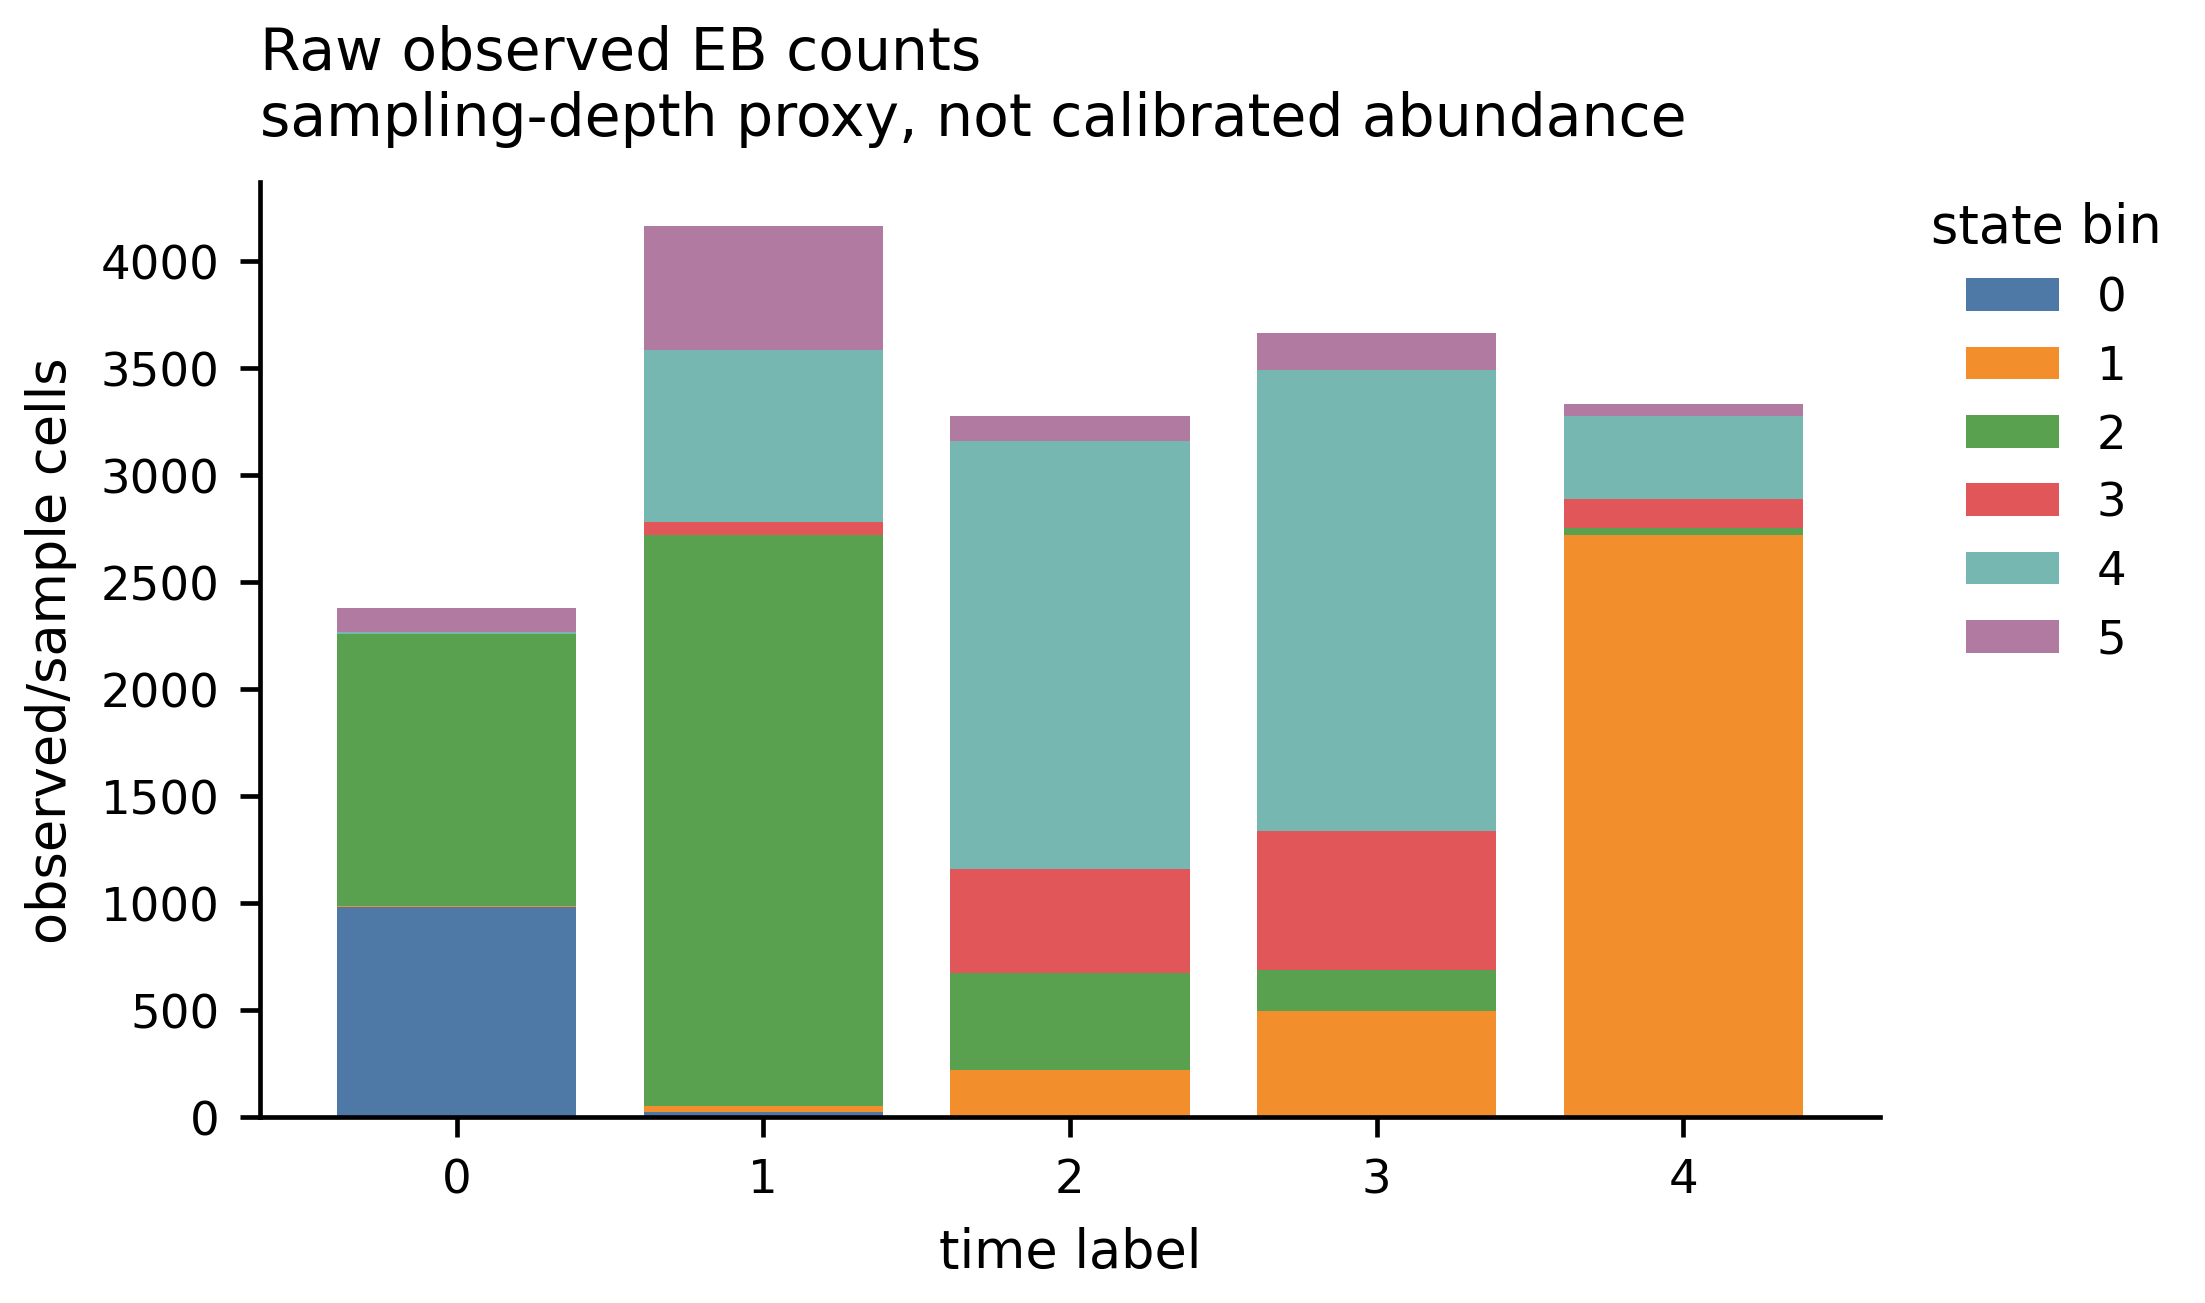

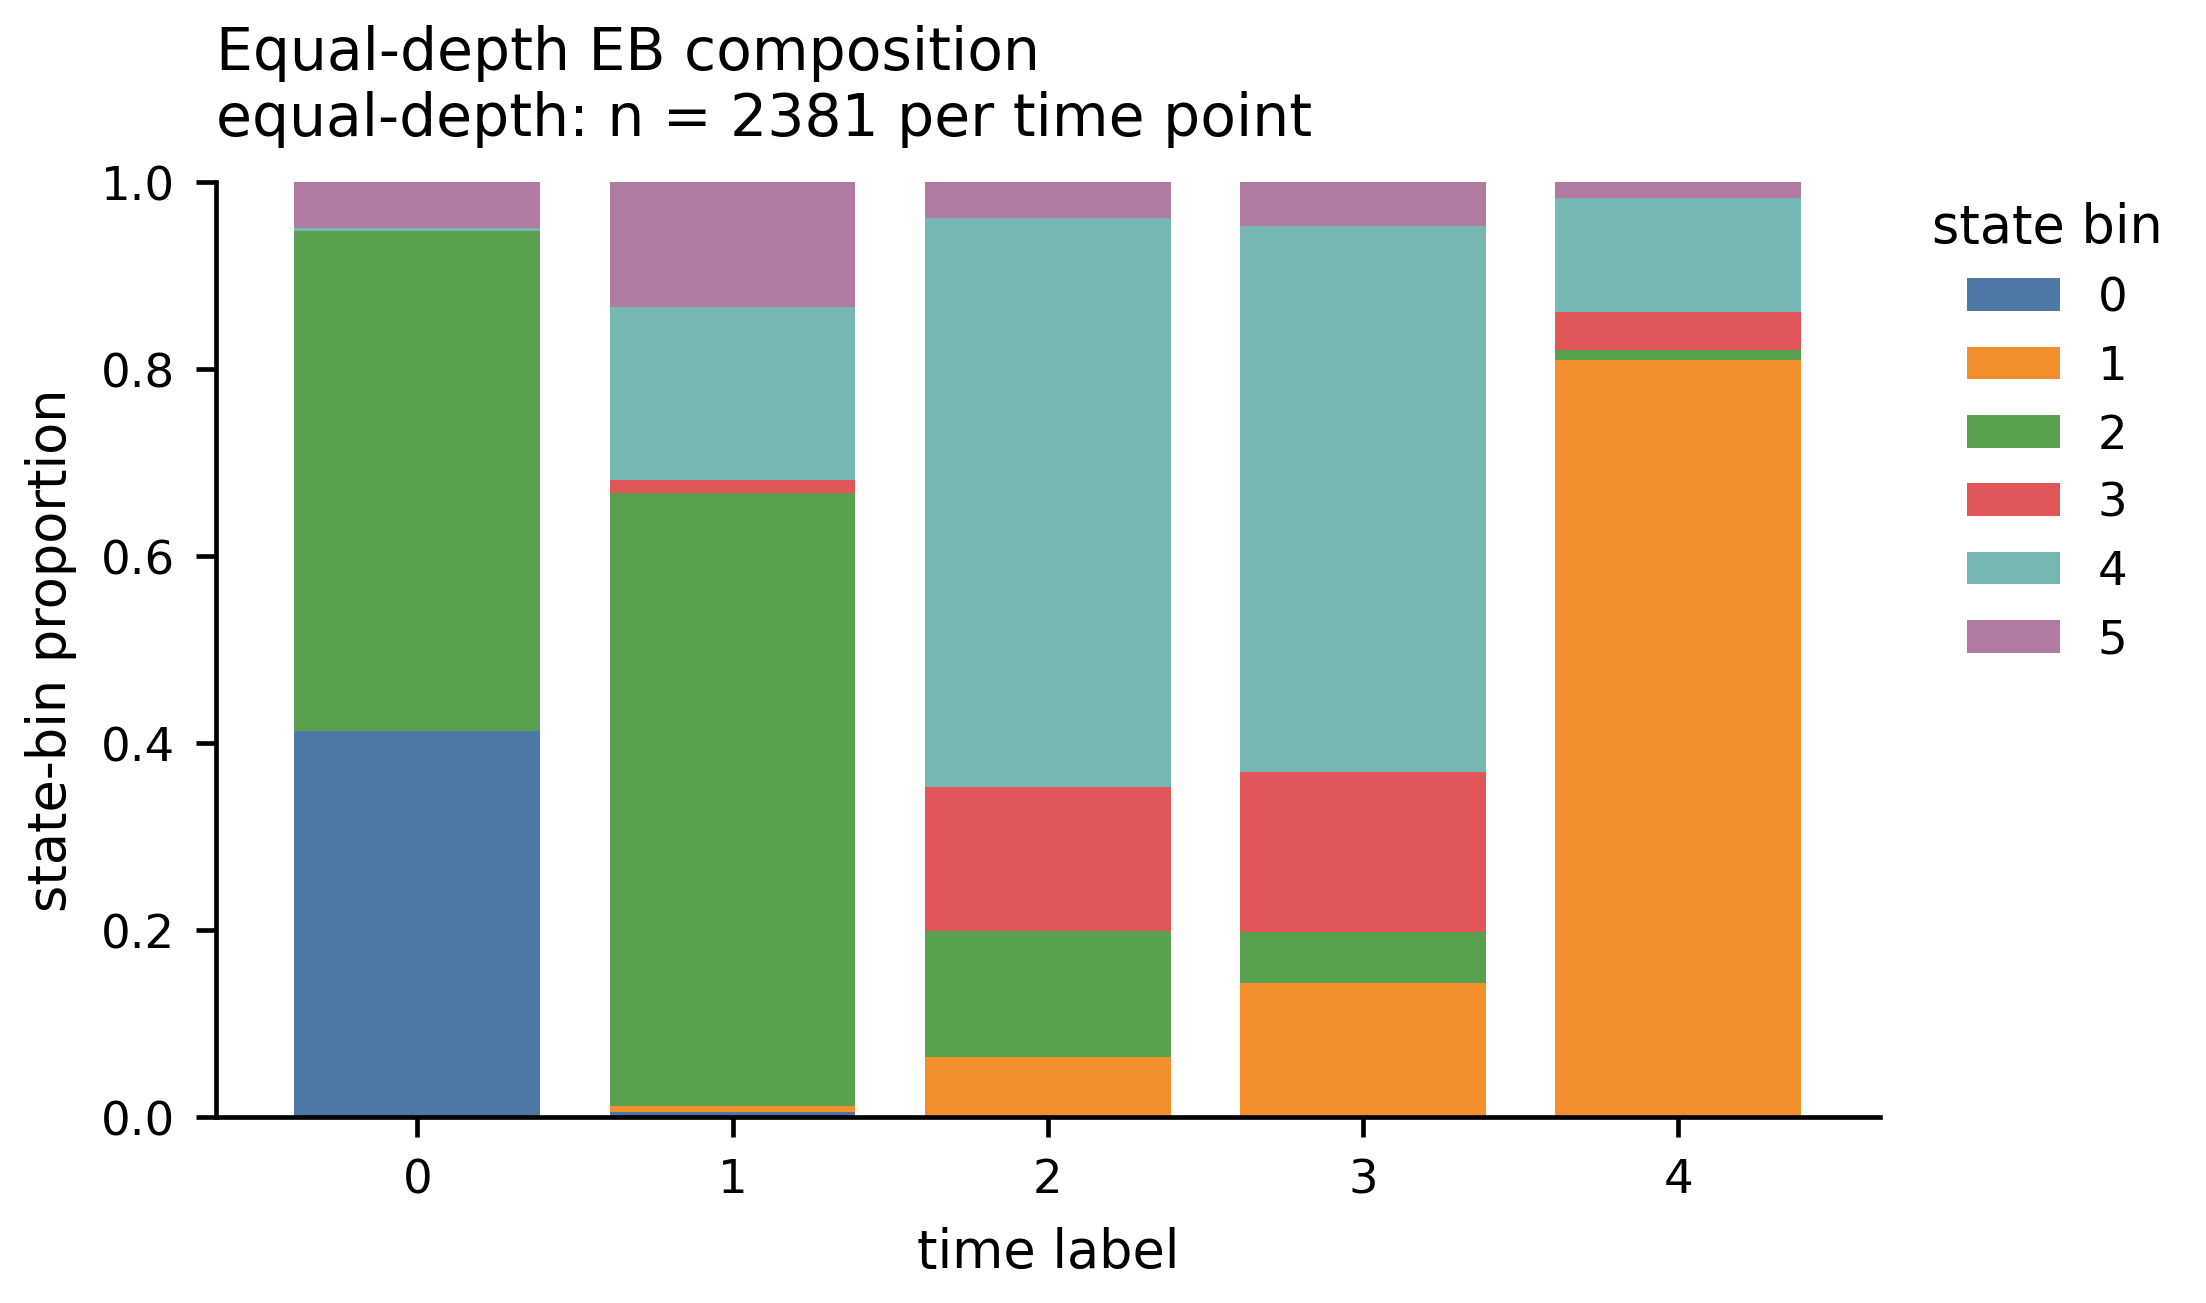

In [18]:
# Final small figures: raw observed EB counts and equal-depth EB composition.
STATE_BIN_COLOR_LIST = [
    "#4E79A7", "#F28E2B", "#59A14F", "#E15759",
    "#76B7B2", "#B07AA1", "#EDC948", "#9C755F",
]
STATE_BIN_COLORS = {b: STATE_BIN_COLOR_LIST[i % len(STATE_BIN_COLOR_LIST)] for i, b in enumerate(all_bins)}


def ordered_state_pivot(frame: pd.DataFrame, value_col: str) -> pd.DataFrame:
    pivot = frame.pivot_table(index="time", columns="state_bin", values=value_col, fill_value=0)
    pivot = pivot.reindex(index=unique_times, columns=all_bins, fill_value=0)
    return pivot


orig_pivot = ordered_state_pivot(counts_by_state, "n_cells")
equal_counts = equal_counts.copy()
equal_counts["proportion"] = equal_counts["n_cells"] / equal_counts["total_time_cells"]
equal_prop_pivot = ordered_state_pivot(equal_counts, "proportion")

fig, ax = plt.subplots(figsize=(5.4, 3.25))
orig_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.78,
    color=[STATE_BIN_COLORS[b] for b in orig_pivot.columns],
    legend=False,
)
ax.set_title("Raw observed EB counts\nsampling-depth proxy, not calibrated abundance", loc="left", pad=8)
ax.set_xlabel("time label")
ax.set_ylabel("observed/sample cells")
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="state bin",
    frameon=False,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
)
save_pub_figure(fig, "fig4_11a_raw_observed_counts")
display_final_png("fig4_11a_raw_observed_counts")

fig, ax = plt.subplots(figsize=(5.4, 3.25))
equal_prop_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.78,
    color=[STATE_BIN_COLORS[b] for b in equal_prop_pivot.columns],
    legend=False,
)
ax.set_title(f"Equal-depth EB composition\nequal-depth: n = {n_min} per time point", loc="left", pad=8)
ax.set_xlabel("time label")
ax.set_ylabel("state-bin proportion")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="state bin",
    frameon=False,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.0,
)
save_pub_figure(fig, "fig4_11b_equal_depth_composition")
display_final_png("fig4_11b_equal_depth_composition")

The bootstrap sweep measures how much the log growth proxy changes when each time point is forced to the same sampling depth.

In [19]:
# Depth-sweep bootstrap counts and log growth proxy.
depth_grid = [d for d in [100, 200, 400, n_min] if d <= n_min]
depth_grid = sorted(set(depth_grid))
bootstrap_count_rows = []
for depth in depth_grid:
    for rep in range(BOOTSTRAP_REPEATS):
        selected = []
        for t in unique_times:
            idx = np.flatnonzero(labels_all == t)
            selected.append(rng.choice(idx, size=depth, replace=False))
        selected = np.concatenate(selected)
        for t in unique_times:
            idx_t = selected[labels_all[selected] == t]
            count_by_bin = pd.Series(state_bins[idx_t]).value_counts()
            for b in all_bins:
                c = int(count_by_bin.get(b, 0))
                bootstrap_count_rows.append({
                    "depth": int(depth), "repeat": int(rep), "time": t, "state_bin": b,
                    "count": c, "proportion": float(c / int(depth)),
                })
boot_counts = pd.DataFrame(bootstrap_count_rows)

In [20]:
eps_growth = 0.5
raw_rows = []
for t0, t1 in zip(unique_times[:-1], unique_times[1:]):
    c0 = counts_by_state[counts_by_state["time"] == t0].set_index("state_bin")
    c1 = counts_by_state[counts_by_state["time"] == t1].set_index("state_bin")
    for b in all_bins:
        n0 = int(c0.loc[b, "n_cells"])
        n1 = int(c1.loc[b, "n_cells"])
        p0 = float(c0.loc[b, "proportion"])
        p1 = float(c1.loc[b, "proportion"])
        raw_rows.append({
            "time_bridge": f"{t0}->{t1}",
            "time_t": t0,
            "time_t_next": t1,
            "state_bin": b,
            "raw_count_t": n0,
            "raw_count_t_next": n1,
            "raw_count_growth_proxy": float(np.log((n1 + eps_growth) / (n0 + eps_growth))),
            "normalized_proportion_change": float(p1 - p0),
        })
raw_growth = pd.DataFrame(raw_rows)

boot_proxy_rows = []
for depth in depth_grid:
    for rep in range(BOOTSTRAP_REPEATS):
        sub = boot_counts[(boot_counts["depth"] == depth) & (boot_counts["repeat"] == rep)]
        for t0, t1 in zip(unique_times[:-1], unique_times[1:]):
            s0 = sub[sub["time"] == t0].set_index("state_bin")
            s1 = sub[sub["time"] == t1].set_index("state_bin")
            for b in all_bins:
                n0 = int(s0.loc[b, "count"])
                n1 = int(s1.loc[b, "count"])
                boot_proxy_rows.append({
                    "depth": int(depth),
                    "repeat": int(rep),
                    "time_bridge": f"{t0}->{t1}",
                    "state_bin": b,
                    "equal_depth_growth_proxy": float(np.log((n1 + eps_growth) / (n0 + eps_growth))),
                })
boot_proxy = pd.DataFrame(boot_proxy_rows)
proxy_summary_all_depths = boot_proxy.groupby(["depth", "time_bridge", "state_bin"]).agg(
    proxy_mean=("equal_depth_growth_proxy", "mean"),
    proxy_ci_low=("equal_depth_growth_proxy", lambda x: float(np.quantile(x, 0.025))),
    proxy_ci_high=("equal_depth_growth_proxy", lambda x: float(np.quantile(x, 0.975))),
).reset_index()
proxy_equal_depth = proxy_summary_all_depths[proxy_summary_all_depths["depth"] == n_min].rename(columns={
    "proxy_mean": "equal_depth_proxy_mean",
    "proxy_ci_low": "equal_depth_proxy_ci_low",
    "proxy_ci_high": "equal_depth_proxy_ci_high",
})

In [21]:
downsampling_table = raw_growth.merge(
    proxy_equal_depth[["time_bridge", "state_bin", "equal_depth_proxy_mean", "equal_depth_proxy_ci_low", "equal_depth_proxy_ci_high"]],
    on=["time_bridge", "state_bin"],
    how="left",
)
ci_width = downsampling_table["equal_depth_proxy_ci_high"] - downsampling_table["equal_depth_proxy_ci_low"]
inside_ci = (downsampling_table["raw_count_growth_proxy"] >= downsampling_table["equal_depth_proxy_ci_low"]) & (downsampling_table["raw_count_growth_proxy"] <= downsampling_table["equal_depth_proxy_ci_high"])
downsampling_table["stable_under_subsampling"] = np.where(inside_ci & (ci_width < 1.0), "stable", "sensitive")
downsampling_table["state_label_source"] = "k-means on standardized PC-20 because EB file has no state/cluster labels"
downsampling_table["abundance_claim_boundary"] = "raw counts reflect sampling depth; not absolute biological abundance"
save_csv(OUT_DIR / "table4_6_eb_downsampling_diagnostics.csv", downsampling_table)
save_csv(CACHE_DIR / "exp9_depth_sweep_growth_proxy.csv", proxy_summary_all_depths)


PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch04/cache/exp9_depth_sweep_growth_proxy.csv')

The adjacent-bridge diagnostic samples endpoints from balanced OT plans. It remains a PC-20 transport diagnostic, not a trained CFM bridge or a growth model.

In [22]:
# Adjacent bridge OT sampled endpoint diagnostics.
# This is an OT sampled endpoint diagnostic, not a trained CFM bridge and not a growth/abundance model.
def bridge_sampling_diagnostic(time_a, time_b, sampling_setting: str, cap: int, seed: int):
    idx_a_all = np.flatnonzero(labels_all == time_a)
    idx_b_all = np.flatnonzero(labels_all == time_b)
    rng_local = np.random.default_rng(seed)
    if sampling_setting == "original_depth":
        n_source = min(len(idx_a_all), int(cap))
        n_target = min(len(idx_b_all), int(cap))
    elif sampling_setting == "equal_depth":
        n_source = n_target = min(len(idx_a_all), len(idx_b_all), int(cap))
    else:
        raise ValueError(f"unknown sampling_setting={sampling_setting}")
    ia = np.sort(rng_local.choice(idx_a_all, size=n_source, replace=False))
    ib = np.sort(rng_local.choice(idx_b_all, size=n_target, replace=False))
    Xa, Xb = pcs_all[ia], pcs_all[ib]
    Cb, scaleb = compute_cost_matrix(Xa, Xb, normalize=True)
    pib, infob = sinkhorn_plan(Cb, epsilon=SINKHORN_EPSILON, return_info=True)
    diagb = coupling_diagnostics(pib, Cb)
    n_sample = min(4096, max(1024, 4 * n_source))
    sampled_i, sampled_j = sample_from_plan(pib, n_sample, seed=seed + 17)
    sampled_endpoint = Xb[sampled_j]
    pred_bins = state_bins[ib][sampled_j]
    target_bins = state_bins[ib]
    pred_prop = pd.Series(pred_bins).value_counts(normalize=True)
    target_prop = pd.Series(target_bins).value_counts(normalize=True)
    bin_err = sum(abs(float(pred_prop.get(k, 0.0)) - float(target_prop.get(k, 0.0))) for k in all_bins)
    return {
        "time_bridge": f"{time_a}->{time_b}",
        "sampling_setting": sampling_setting,
        "n_source": int(n_source),
        "n_target": int(n_target),
        "endpoint_mmd_pc20": mmd_rbf(sampled_endpoint, Xb),
        "sliced_w2_pc20": sliced_w2(sampled_endpoint, Xb, seed=seed + 23),
        "state_bin_terminal_proportion_error": float(bin_err),
        "expected_cost_normalized": float(diagb["expected_cost"]),
        "effective_support": float(diagb["effective_support"]),
        "sinkhorn_converged": bool(infob["sinkhorn_converged"]),
        "diagnostic_type": "ot_sampled_endpoint_diagnostic_not_trained_cfm",
        "claim_boundary": "standardized PC-20 OT sampled endpoint diagnostic; not trained CFM, not observed paired histories, not growth or calibrated abundance",
    }

In [23]:
bridge_cap = 120 if SMOKE_MODE else 800
bridge_table_path = OUT_DIR / "table4_6b_eb_bridge_sampling_diagnostics.csv"
force_recompute_bridge = os.environ.get("CH04_FORCE_RECOMPUTE_BRIDGE_DIAGNOSTICS", "0") == "1"

if bridge_table_path.exists() and bridge_table_path.stat().st_size > 0 and not force_recompute_bridge:
    bridge_sampling_table = pd.read_csv(bridge_table_path)
else:
    bridge_rows = []
    for bridge_id, (a, b) in enumerate(zip(unique_times[:-1], unique_times[1:])):
        bridge_rows.append(bridge_sampling_diagnostic(a, b, "original_depth", cap=bridge_cap, seed=410 + 10 * bridge_id))
        bridge_rows.append(bridge_sampling_diagnostic(a, b, "equal_depth", cap=min(bridge_cap, n_min), seed=411 + 10 * bridge_id))
    bridge_sampling_table = pd.DataFrame(bridge_rows)
    save_csv(bridge_table_path, bridge_sampling_table)
save_csv(CACHE_DIR / "exp9_adjacent_bridge_ot_sampled_endpoint_diagnostics.csv", bridge_sampling_table)
remember_source("table4_6b_eb_bridge_sampling_diagnostics.csv", bridge_table_path)
bridge_sampling_table

,time_bridge,sampling_setting,n_source,n_target,endpoint_mmd_pc20,sliced_w2_pc20,state_bin_terminal_proportion_error,expected_cost_normalized,effective_support,sinkhorn_converged,diagnostic_type,claim_boundary
0,0->1,original_depth,800,800,0.000318,0.034742,0.008750,0.651583,52318.447634,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
1,0->1,equal_depth,800,800,0.000260,0.033158,0.018750,0.639683,50712.389779,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
2,1->2,original_depth,800,800,0.000339,0.043869,0.028125,0.531669,22941.054524,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
3,1->2,equal_depth,800,800,0.000248,0.034466,0.016875,0.529392,23532.036573,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
4,2->3,original_depth,800,800,0.000237,0.042196,0.023125,0.398269,16550.004814,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
5,2->3,equal_depth,800,800,0.000194,0.035598,0.019375,0.390599,15453.166955,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
6,3->4,original_depth,800,800,0.000306,0.038523,0.013750,0.499373,21657.031657,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
7,3->4,equal_depth,800,800,0.000256,0.038160,0.011875,0.502330,20608.273555,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...


In [24]:
boundary_rows = [
    {"assumption": "state labels", "status": "coarse k-means bins used", "claim_boundary": "diagnostic bins, not validated cell types"},
    {"assumption": "cell counts", "status": "observed destructive snapshot counts", "claim_boundary": "sampling depth, not absolute biological abundance"},
    {"assumption": "subsampling", "status": f"equal-depth bootstrap repeats={BOOTSTRAP_REPEATS}", "claim_boundary": "stability diagnostic only"},
    {"assumption": "adjacent bridge OT", "status": "original-depth and equal-depth OT sampled endpoint diagnostics in PC-20", "claim_boundary": "diagnostic only; not trained CFM and not observed paired histories"},
]
boundary_table = pd.DataFrame(boundary_rows)
save_csv(OUT_DIR / "table4_7_biological_assumption_boundary.csv", boundary_table)

PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch04/table4_7_biological_assumption_boundary.csv')

Finally, plot raw-count growth proxies against equal-depth bootstrap intervals. This is a sampling-depth diagnostic and not an abundance calibration: the visual emphasizes which raw proxies fall outside the equal-depth 95% intervals.

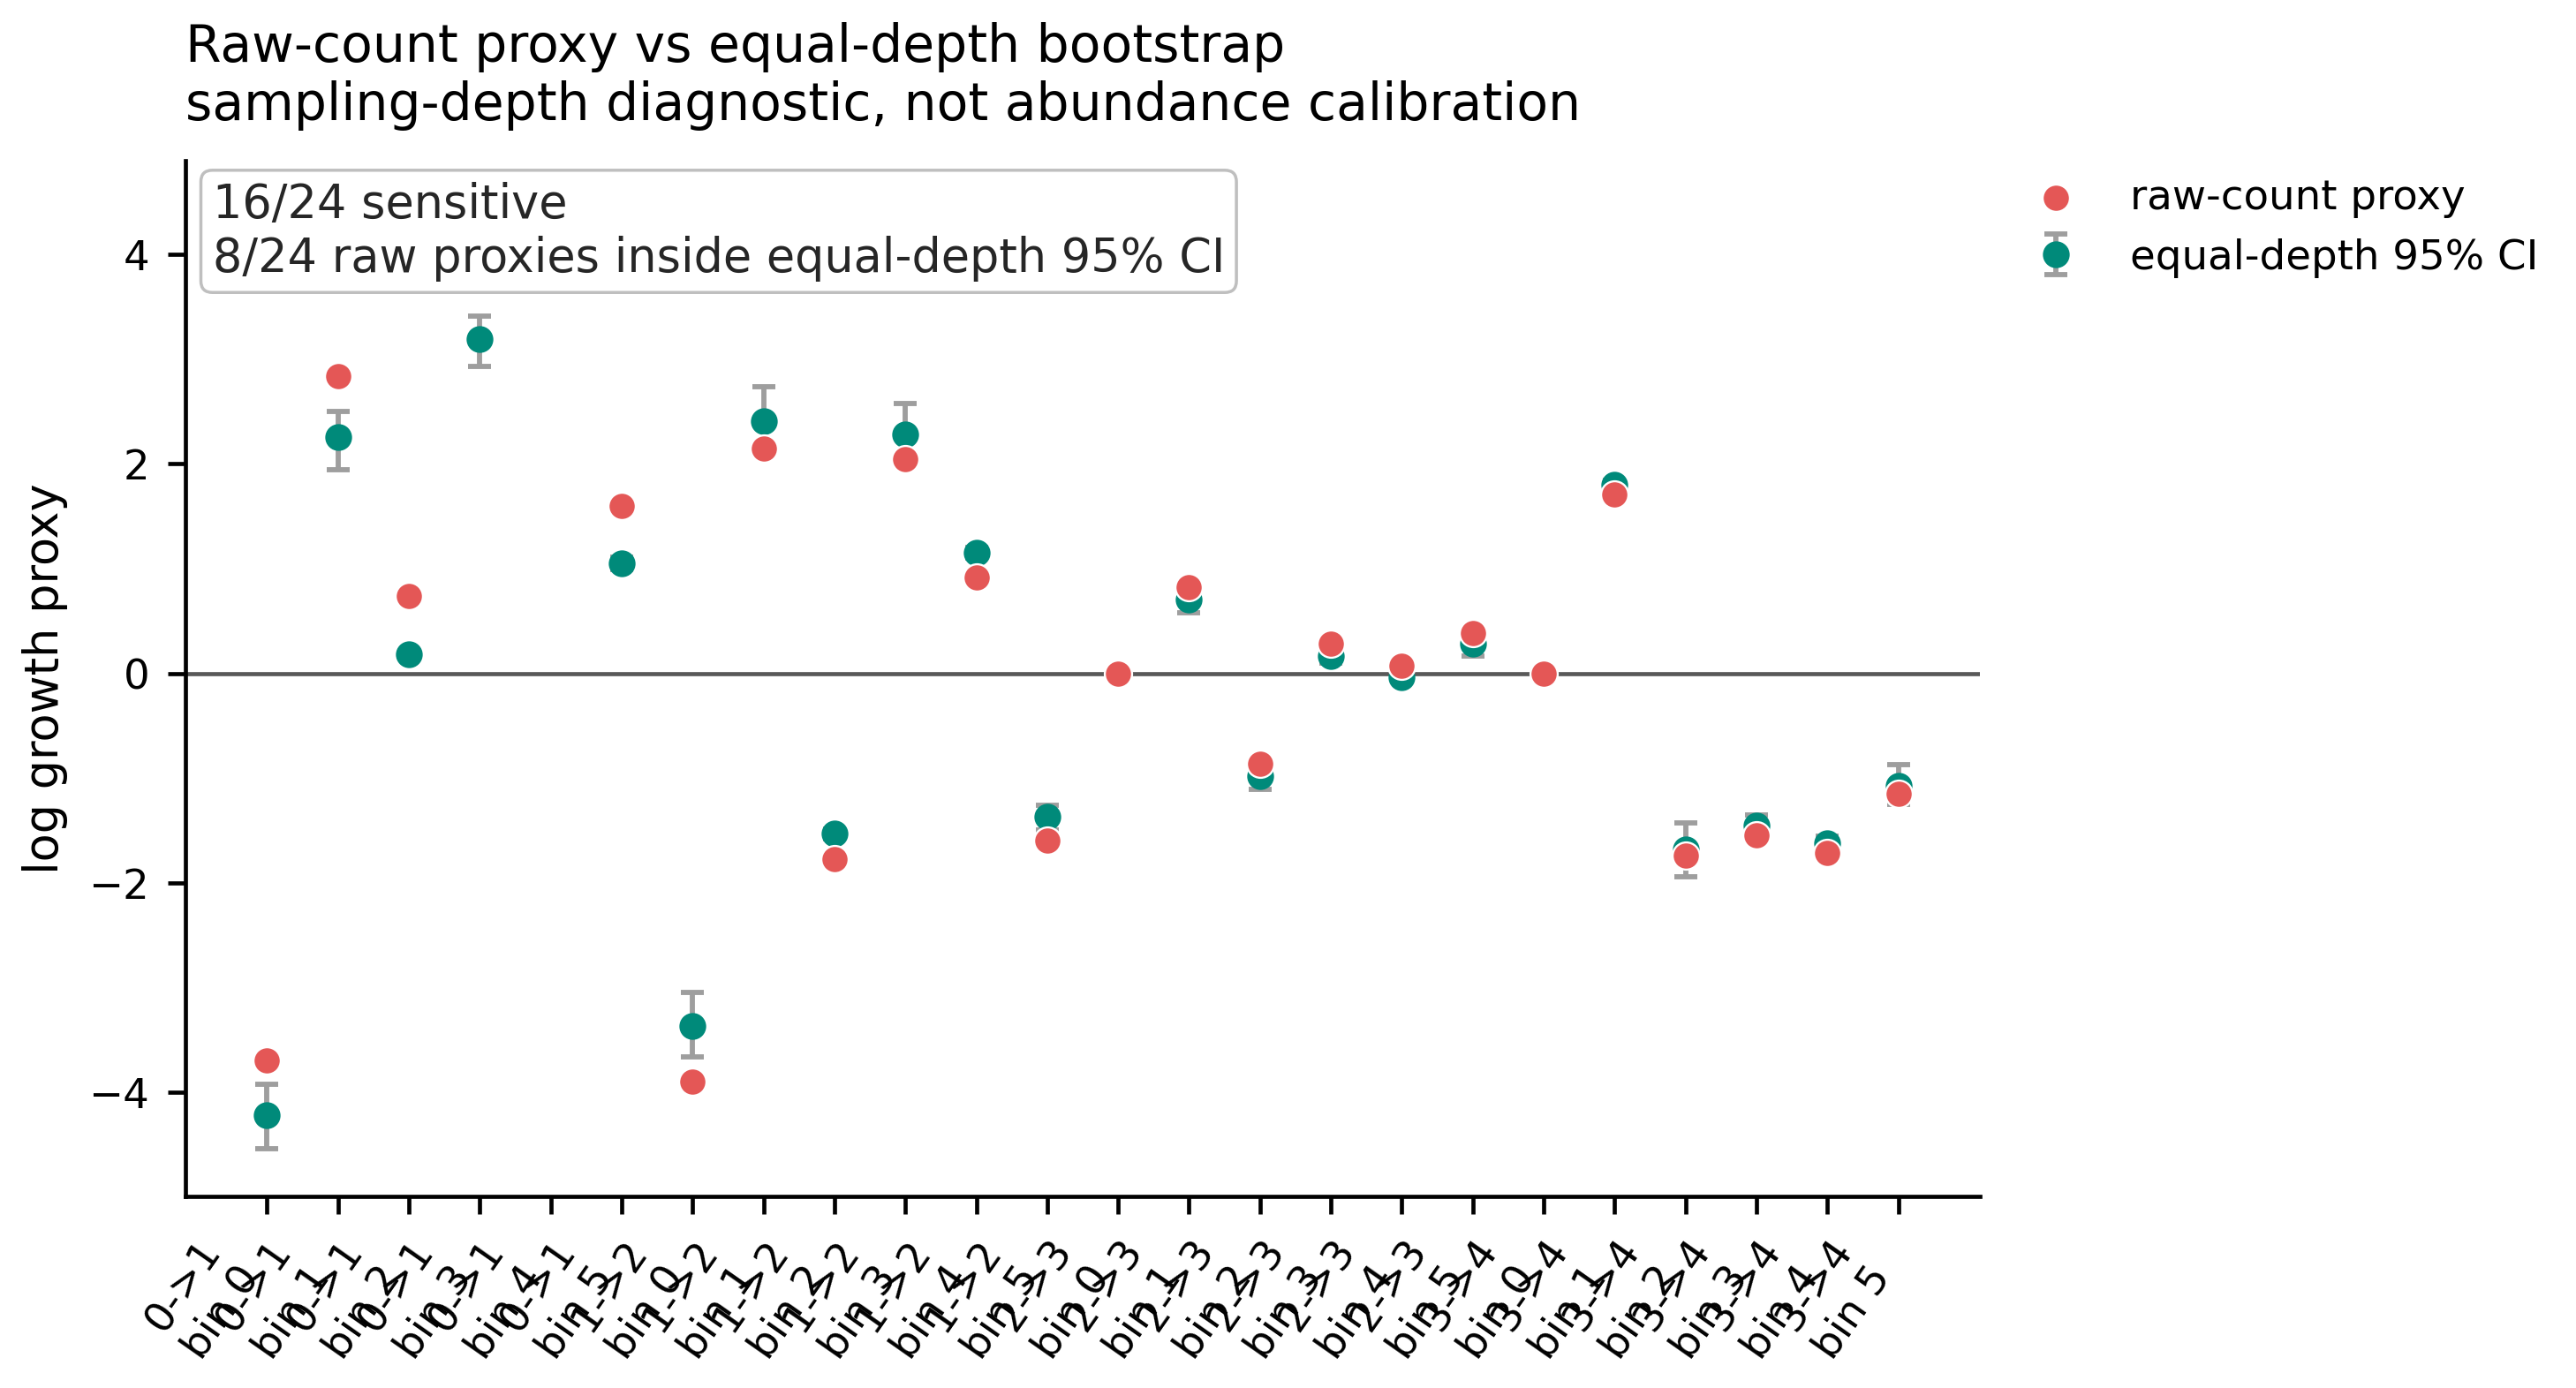

,time_bridge,time_t,time_t_next,state_bin,raw_count_t,raw_count_t_next,raw_count_growth_proxy,normalized_proportion_change,equal_depth_proxy_mean,equal_depth_proxy_ci_low,equal_depth_proxy_ci_high,stable_under_subsampling,state_label_source,abundance_claim_boundary,label
0,0->1,0,1,0,982,24,-3.691427,-0.406667,-4.217402,-4.538725,-3.919686,sensitive,k-means on standardized PC-20 because EB file ...,raw counts reflect sampling depth; not absolut...,0->1\nbin 0
1,0->1,0,1,1,1,25,2.833213,0.005585,2.256235,1.945910,2.499802,sensitive,k-means on standardized PC-20 because EB file ...,raw counts reflect sampling depth; not absolut...,0->1\nbin 1
2,0->1,0,1,2,1272,2671,0.741657,0.107375,0.181583,0.165196,0.197594,sensitive,k-means on standardized PC-20 because EB file ...,raw counts reflect sampling depth; not absolut...,0->1\nbin 2
3,0->1,0,1,3,1,63,3.745575,0.014713,3.192313,2.924517,3.407247,sensitive,k-means on standardized PC-20 because EB file ...,raw counts reflect sampling depth; not absolut...,0->1\nbin 3
4,0->1,0,1,4,9,803,4.437685,0.189110,3.879052,3.830299,3.930428,sensitive,k-means on standardized PC-20 because EB file ...,raw counts reflect sampling depth; not absolut...,0->1\nbin 4


In [25]:
# Final small figure: raw-count proxy versus equal-depth bootstrap intervals.
downsampling_plot_path = remember_source(
    "table4_6_eb_downsampling_diagnostics.csv",
    resolve_required_artifact("table4_6_eb_downsampling_diagnostics.csv", [OUT_DIR]),
)
downsampling_table = pd.read_csv(downsampling_plot_path)
plot_df = downsampling_table.copy()
plot_df["state_bin"] = plot_df["state_bin"].astype(str)
plot_df = plot_df.sort_values(["time_bridge", "state_bin"]).reset_index(drop=True)
plot_df["label"] = plot_df["time_bridge"].astype(str) + "\nbin " + plot_df["state_bin"].astype(str)

inside_ci = (
    (plot_df["raw_count_growth_proxy"] >= plot_df["equal_depth_proxy_ci_low"])
    & (plot_df["raw_count_growth_proxy"] <= plot_df["equal_depth_proxy_ci_high"])
)
sensitive_count = int((plot_df["stable_under_subsampling"] == "sensitive").sum())
inside_count = int(inside_ci.sum())
n_comparisons = int(len(plot_df))

fig, ax = plt.subplots(figsize=(7.1, 3.9))
x = np.arange(n_comparisons)
y = plot_df["equal_depth_proxy_mean"].to_numpy(dtype=float)
yerr = np.vstack([
    y - plot_df["equal_depth_proxy_ci_low"].to_numpy(dtype=float),
    plot_df["equal_depth_proxy_ci_high"].to_numpy(dtype=float) - y,
])
ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    color=PALETTE["ot"],
    ecolor="0.62",
    elinewidth=1.0,
    capsize=2.2,
    markersize=4.2,
    label="equal-depth 95% CI",
)
ax.scatter(
    x,
    plot_df["raw_count_growth_proxy"].to_numpy(dtype=float),
    color=PALETTE["diagnostic"],
    edgecolor="white",
    linewidth=0.4,
    s=28,
    zorder=3,
    label="raw-count proxy",
)
ax.axhline(0.0, color="0.35", linewidth=0.8, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=55, ha="right")
ax.set_ylabel("log growth proxy")
ax.set_title(
    "Raw-count proxy vs equal-depth bootstrap\nsampling-depth diagnostic, not abundance calibration",
    loc="left",
    pad=8,
)
ax.text(
    0.015,
    0.98,
    f"{sensitive_count}/{n_comparisons} sensitive\n{inside_count}/{n_comparisons} raw proxies inside equal-depth 95% CI",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="0.15",
    bbox={"facecolor": "white", "edgecolor": "0.75", "boxstyle": "round,pad=0.25", "linewidth": 0.6},
)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1.0), loc="upper left", borderaxespad=0.0)
save_pub_figure(fig, "fig4_11c_sampling_depth_bootstrap_sensitivity")
display_final_png("fig4_11c_sampling_depth_bootstrap_sensitivity")
plot_df.head()

## Exp 9b. WFR-FM Sampling-Depth Sensitivity

Tutorial goal: load the internal WFR-FM sampling-depth sensitivity outputs and audit how the growth readout changes under raw observed depth versus equal-depth control.

The WFR-FM outputs are read as a mass-convention sensitivity diagnostic. They are not calibrated biological abundance measurements. The final small figures below show only the raw-minus-equal growth heatmap and a compact agreement summary.

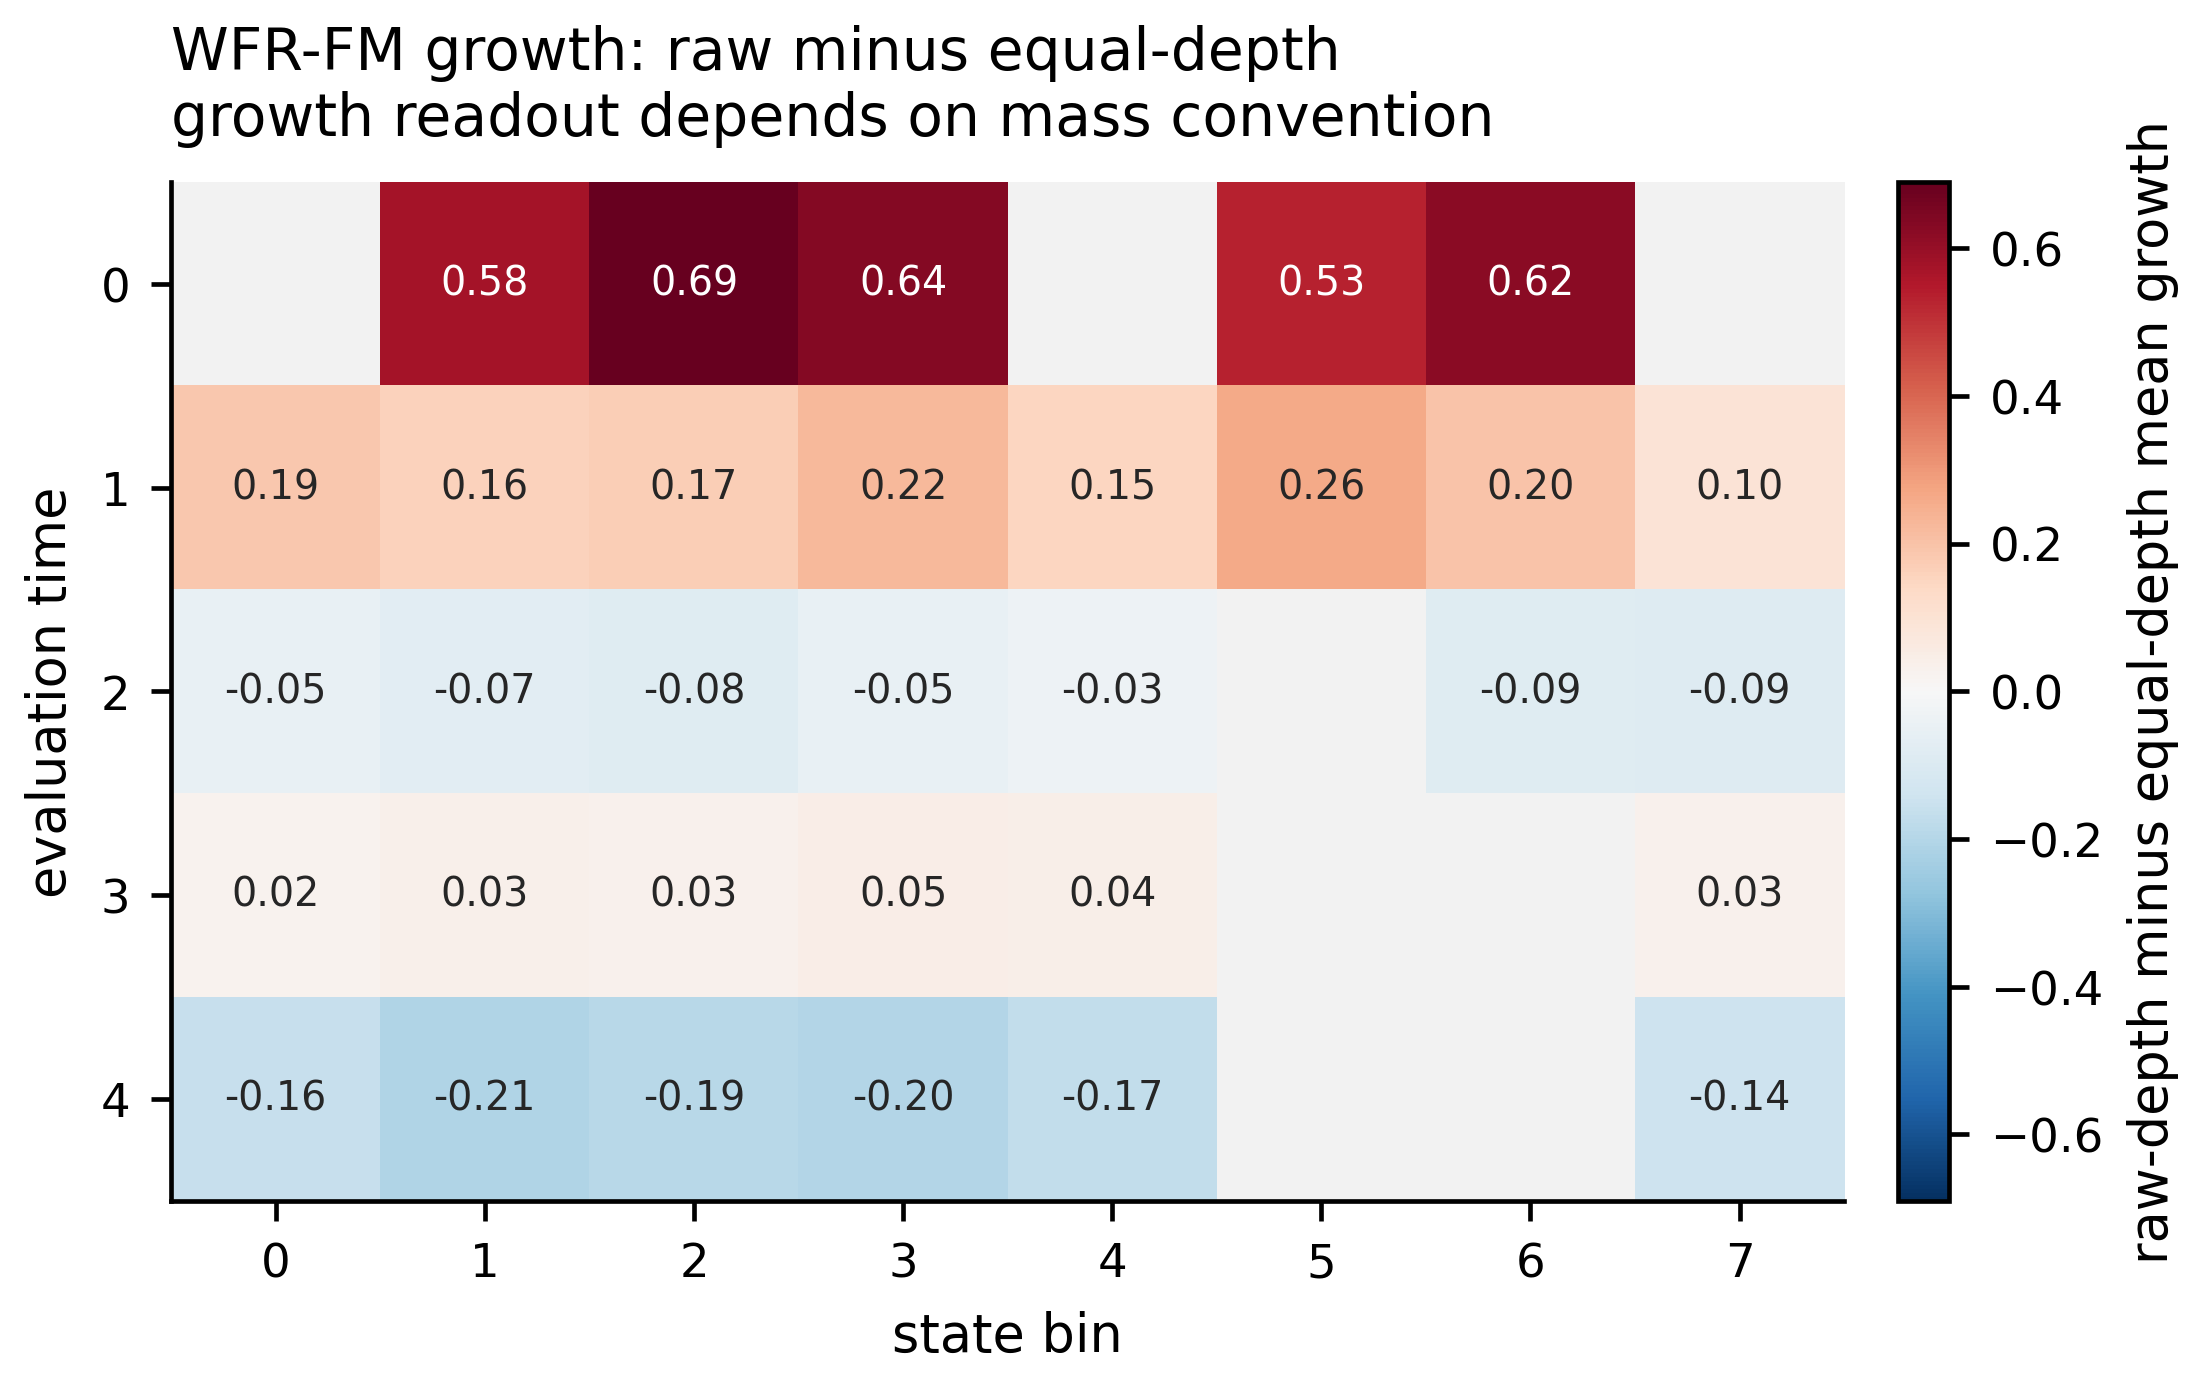

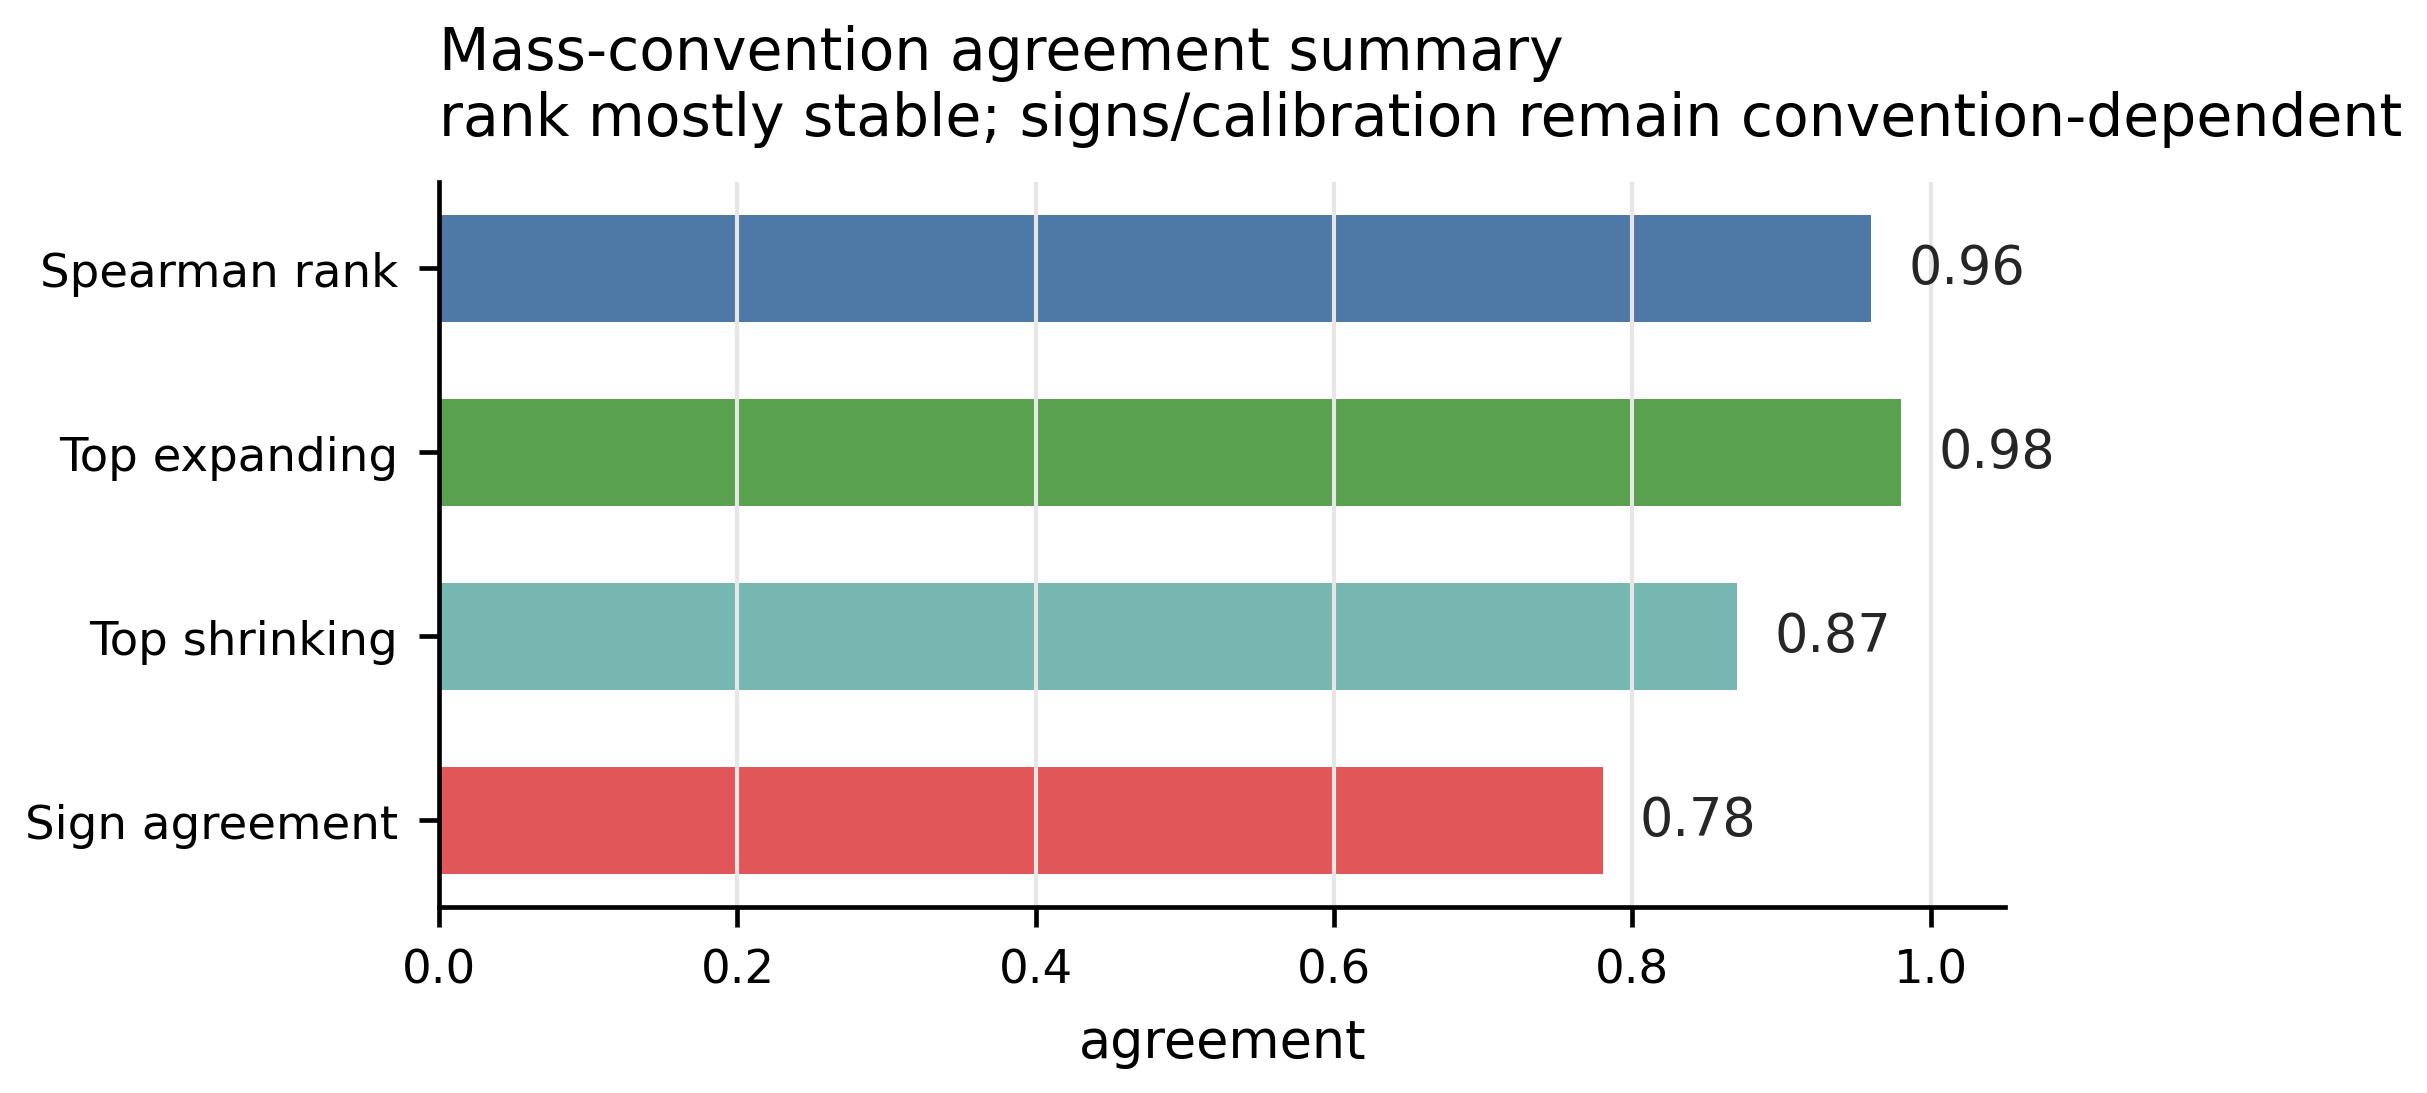

WFR-FM source summary:
{'implementation': 'internal_minimal_wfrfm', 'output_suffix': 'full', 'epochs': 300, 'equal_seeds': [42, 43, 44], 'raw_observed_depth_was_capped': False}


,metric,value,display_value
0,Spearman rank,0.959524,0.96
1,Top expanding,0.977778,0.98
2,Top shrinking,0.866667,0.87
3,Sign agreement,0.778571,0.78


In [26]:
from matplotlib.colors import TwoSlopeNorm


def resolve_wfrfm_output_suffix() -> str:
    env_suffix = os.environ.get("CH04_WFRFM_OUTPUT_SUFFIX")
    if env_suffix is not None:
        return env_suffix.strip().lstrip("_")
    full_summary = OUT_DIR / "wfrfm_sampling_sensitivity_summary_full.json"
    return "full" if full_summary.exists() else ""


WFRFM_OUTPUT_SUFFIX = resolve_wfrfm_output_suffix()


def wfrfm_output_name(stem: str, ext: str) -> str:
    suffix = WFRFM_OUTPUT_SUFFIX.strip().lstrip("_")
    return f"{stem}_{suffix}.{ext}" if suffix else f"{stem}.{ext}"


wfrfm_growth_path = remember_source(
    "table4_6c_wfrfm_growth_by_bin_full.csv",
    resolve_required_artifact(wfrfm_output_name("table4_6c_wfrfm_growth_by_bin", "csv"), [OUT_DIR]),
)
wfrfm_sensitivity_path = remember_source(
    "table4_6d_wfrfm_sampling_sensitivity_full.csv",
    resolve_required_artifact(wfrfm_output_name("table4_6d_wfrfm_sampling_sensitivity", "csv"), [OUT_DIR]),
)
wfrfm_summary_path = remember_source(
    "wfrfm_sampling_sensitivity_summary_full.json",
    resolve_required_artifact(wfrfm_output_name("wfrfm_sampling_sensitivity_summary", "json"), [OUT_DIR]),
)

wfrfm_growth_by_bin = pd.read_csv(wfrfm_growth_path)
wfrfm_sampling_sensitivity = pd.read_csv(wfrfm_sensitivity_path)
wfrfm_summary = json.loads(wfrfm_summary_path.read_text())

if WFRFM_OUTPUT_SUFFIX == "full":
    assert wfrfm_summary.get("smoke") is False, "Full WFR-FM output must not be smoke mode."
    assert int(wfrfm_summary.get("epochs")) == 300, "Full WFR-FM output must use 300 epochs."
    assert wfrfm_summary.get("raw_observed_depth_was_capped") is False, "Full WFR-FM raw observed depth must be uncapped."
    assert wfrfm_summary.get("external_baseline_runtime_dependency") is False, "Exp 9b must use the internal WFR-FM implementation."

growth_plot = wfrfm_growth_by_bin.copy()
growth_plot["eval_time"] = pd.to_numeric(growth_plot["eval_time"])
growth_plot["state_bin"] = growth_plot["state_bin"].astype(str)
growth_plot["mean_g"] = pd.to_numeric(growth_plot["mean_g"], errors="coerce")

mean_growth = growth_plot.groupby(["setting", "eval_time", "state_bin"], as_index=False)["mean_g"].mean()
raw_growth_grid = mean_growth[mean_growth["setting"] == "raw_observed_depth"].pivot_table(
    index="eval_time", columns="state_bin", values="mean_g", aggfunc="mean"
)
equal_growth_grid = mean_growth[mean_growth["setting"] == "equal_depth"].pivot_table(
    index="eval_time", columns="state_bin", values="mean_g", aggfunc="mean"
)
eval_order = sorted(set(raw_growth_grid.index).union(equal_growth_grid.index))
bin_order = sorted(
    set(raw_growth_grid.columns).union(equal_growth_grid.columns),
    key=lambda s: int(s) if str(s).isdigit() else str(s),
)
wfrfm_raw_minus_equal = raw_growth_grid.reindex(eval_order, columns=bin_order) - equal_growth_grid.reindex(eval_order, columns=bin_order)

fig, ax = plt.subplots(figsize=(5.4, 3.45))
matrix = wfrfm_raw_minus_equal.to_numpy(dtype=float)
absmax = float(np.nanmax(np.abs(matrix))) if np.isfinite(matrix).any() else 1.0
if absmax == 0:
    absmax = 1.0
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#F2F2F2")
im = ax.imshow(
    np.ma.masked_invalid(matrix),
    aspect="auto",
    cmap=cmap,
    norm=TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax),
)
ax.set_title("WFR-FM growth: raw minus equal-depth\ngrowth readout depends on mass convention", loc="left", pad=8)
ax.set_xlabel("state bin")
ax.set_ylabel("evaluation time")
ax.set_xticks(np.arange(len(bin_order)))
ax.set_xticklabels(bin_order)
ax.set_yticks(np.arange(len(eval_order)))
ax.set_yticklabels([f"{t:g}" for t in eval_order])
ax.set_facecolor("#F2F2F2")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if np.isfinite(matrix[i, j]):
            text_color = "white" if abs(matrix[i, j]) > 0.6 * absmax else "0.15"
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=6.8, color=text_color)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("raw-depth minus equal-depth mean growth")
save_pub_figure(fig, "fig4_11d_wfrfm_raw_minus_equal_growth_heatmap")
display_final_png("fig4_11d_wfrfm_raw_minus_equal_growth_heatmap")

agreement_values = {
    "Spearman rank": float(wfrfm_sampling_sensitivity["spearman_growth_rank"].mean()),
    "Top expanding": float(wfrfm_sampling_sensitivity["top_expanding_overlap_k3"].mean()),
    "Top shrinking": float(wfrfm_sampling_sensitivity["top_shrinking_overlap_k3"].mean()),
    "Sign agreement": float(wfrfm_sampling_sensitivity["sign_agreement"].mean()),
}
wfrfm_agreement_summary = pd.DataFrame(
    [{"metric": key, "value": value, "display_value": round(value, 2)} for key, value in agreement_values.items()]
)

fig, ax = plt.subplots(figsize=(5.1, 2.75))
ypos = np.arange(len(wfrfm_agreement_summary))
bar_colors = ["#4E79A7", "#59A14F", "#76B7B2", "#E15759"]
ax.barh(ypos, wfrfm_agreement_summary["display_value"], color=bar_colors, height=0.58)
ax.set_yticks(ypos)
ax.set_yticklabels(wfrfm_agreement_summary["metric"])
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("agreement")
ax.set_title(
    "Mass-convention agreement summary\nrank mostly stable; signs/calibration remain convention-dependent",
    loc="left",
    pad=8,
)
for y, val in zip(ypos, wfrfm_agreement_summary["display_value"]):
    ax.text(min(val + 0.025, 1.02), y, f"{val:.2f}", va="center", ha="left", fontsize=9, color="0.15")
ax.grid(axis="x", color="0.9", linewidth=0.7)
save_pub_figure(fig, "fig4_11e_wfrfm_mass_convention_agreement_summary")
display_final_png("fig4_11e_wfrfm_mass_convention_agreement_summary")

print("WFR-FM source summary:")
print({
    "implementation": wfrfm_summary.get("implementation"),
    "output_suffix": wfrfm_summary.get("output_suffix"),
    "epochs": wfrfm_summary.get("epochs"),
    "equal_seeds": wfrfm_summary.get("equal_seeds"),
    "raw_observed_depth_was_capped": wfrfm_summary.get("raw_observed_depth_was_capped"),
})
display(wfrfm_agreement_summary)

## Exp 10. Stochastic Bridge Demo

Tutorial goal: show that stochastic bridge width is a separate path-family assumption from the EB sampling-depth and WFR-FM mass-convention diagnostics.

This is a synthetic normalized demo. The point clouds are not EB observations and are not evidence for calibrated abundance, growth, or state uncertainty.

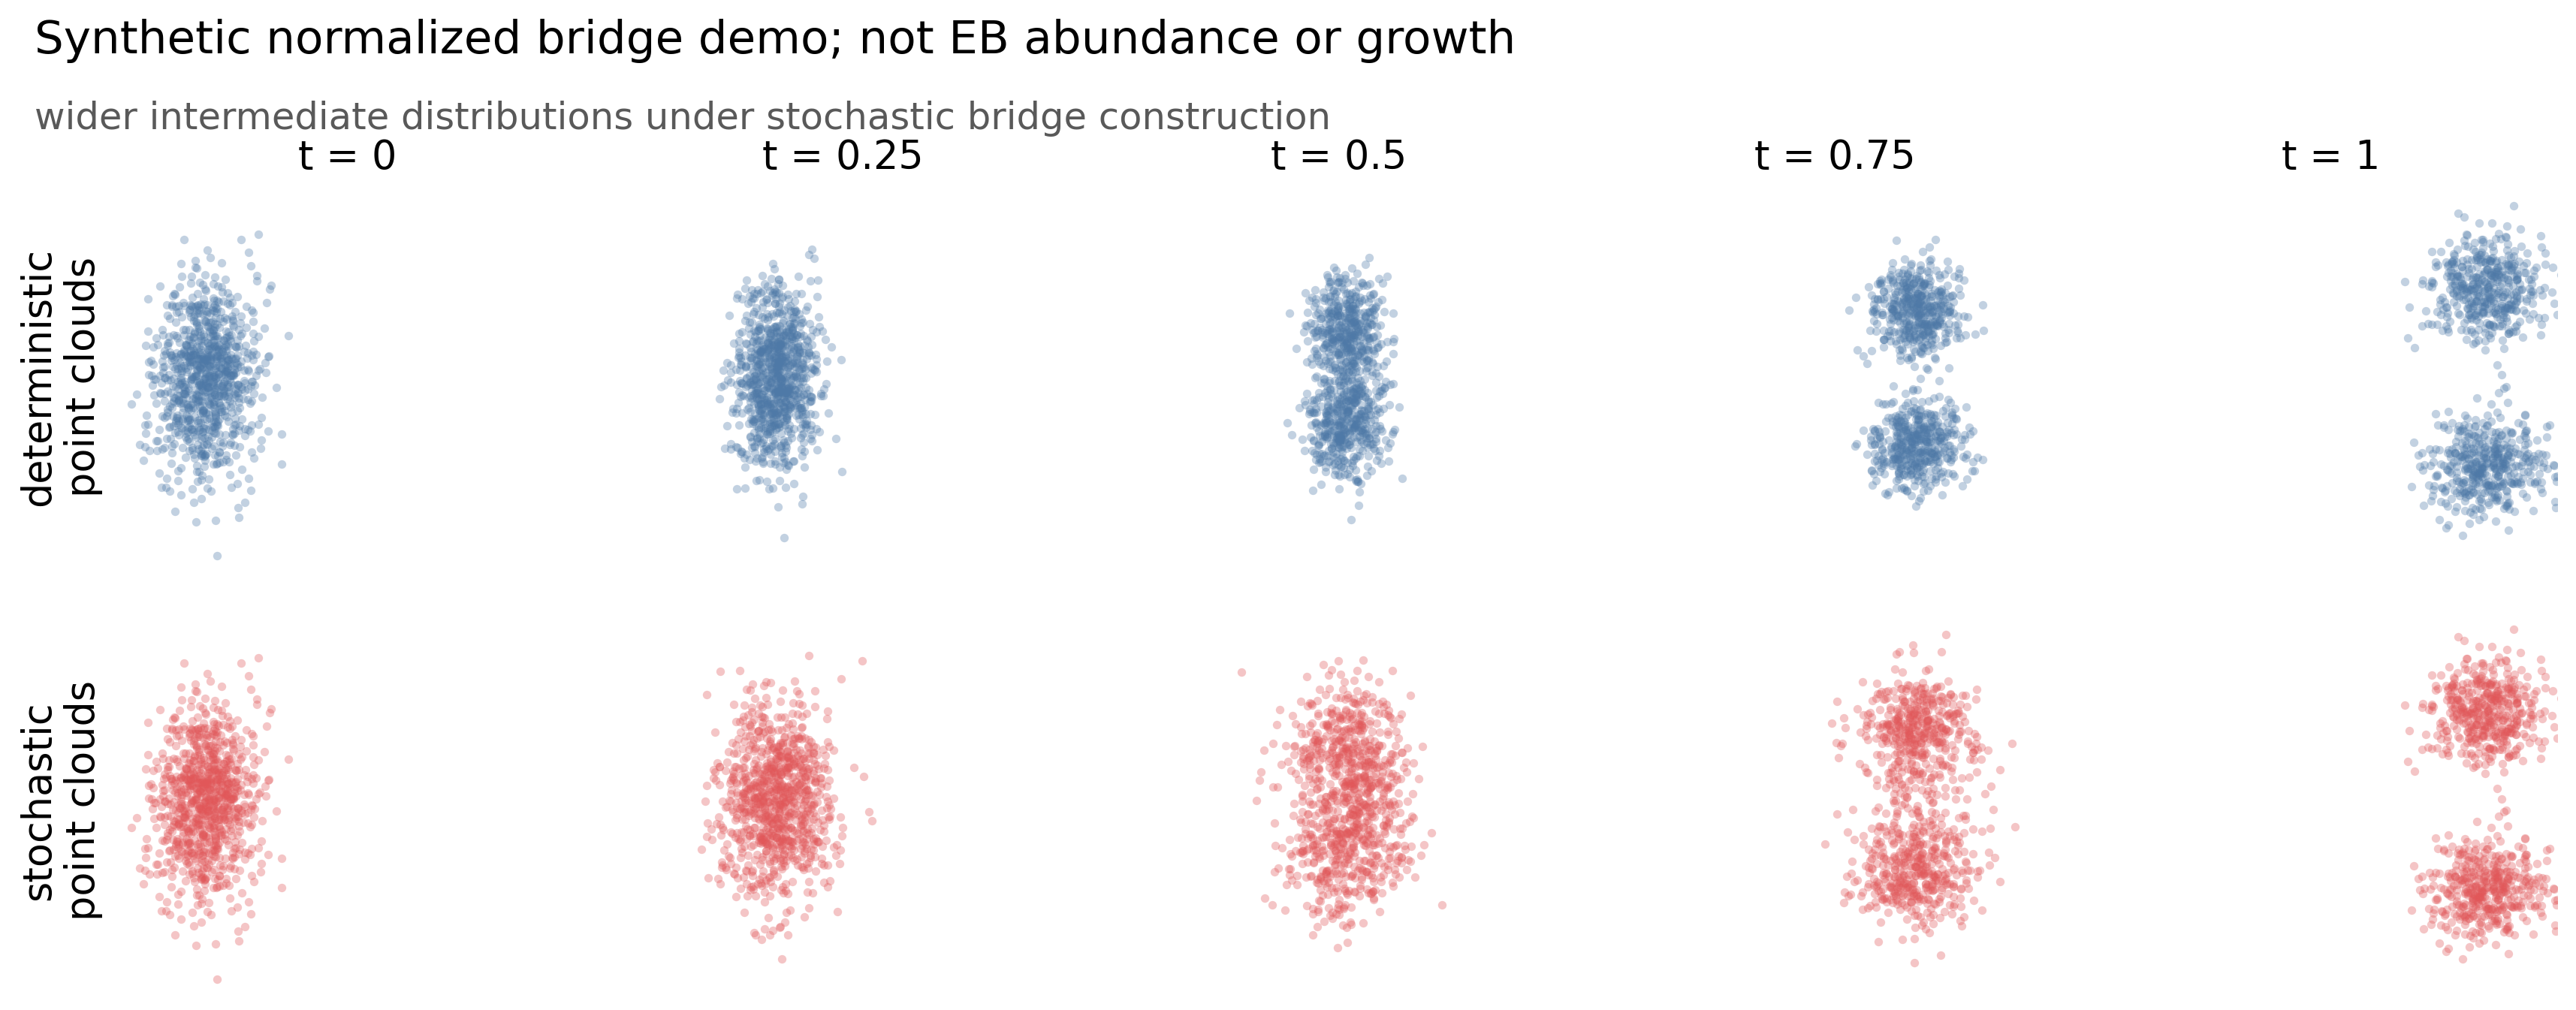

PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch04/cache/exp10_stochastic_bridge_manifest.json')

In [27]:
def synthetic_bridge_samples(n=900, seed=42):
    rng = np.random.default_rng(seed)
    x0 = rng.normal(loc=[-1.5, 0.0], scale=[0.25, 0.45], size=(n, 2))
    mix = rng.uniform(size=n) < 0.5
    x1 = np.empty((n, 2))
    x1[mix] = rng.normal(loc=[1.4, 0.8], scale=[0.28, 0.25], size=(mix.sum(), 2))
    x1[~mix] = rng.normal(loc=[1.4, -0.8], scale=[0.28, 0.25], size=((~mix).sum(), 2))
    return x0.astype(np.float32), x1.astype(np.float32)


bridge_manifest_path = remember_source(
    "cache/exp10_stochastic_bridge_manifest.json",
    resolve_required_artifact("exp10_stochastic_bridge_manifest.json", [CACHE_DIR, OUT_DIR / "cache"]),
)
bridge_manifest = json.loads(bridge_manifest_path.read_text())

x0_syn, x1_syn = synthetic_bridge_samples()
t_grid_demo = [0, 0.25, 0.5, 0.75, 1]
rng = np.random.default_rng(401)
fig, axes = plt.subplots(2, len(t_grid_demo), figsize=(8.3, 3.25), sharex=True, sharey=True)
for col, tval in enumerate(t_grid_demo):
    det = (1 - tval) * x0_syn + tval * x1_syn
    noise_scale = 0.44 * math.sqrt(max(tval * (1 - tval), 0.0))
    stoch = det + rng.normal(scale=noise_scale, size=det.shape)
    for row, pts, label, color in [
        (0, det, "deterministic\npoint clouds", "#4E79A7"),
        (1, stoch, "stochastic\npoint clouds", "#E15759"),
    ]:
        ax = axes[row, col]
        ax.scatter(pts[:, 0], pts[:, 1], s=3.8, alpha=0.34, linewidths=0, color=color)
        if row == 0:
            ax.set_title(f"t = {tval:g}", fontsize=9, pad=4)
        if col == 0:
            ax.set_ylabel(label)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
axes[0, 0].set_xlim(-2.35, 2.1)
axes[0, 0].set_ylim(-1.75, 1.75)
fig.suptitle("Synthetic normalized bridge demo; not EB abundance or growth", x=0.02, y=0.99, ha="left", fontsize=10.5)
fig.text(
    0.02,
    0.91,
    "wider intermediate distributions under stochastic bridge construction",
    ha="left",
    va="top",
    fontsize=8.5,
    color="0.35",
)
save_pub_figure(fig, "fig4_11f_stochastic_bridge_demo")
display_final_png("fig4_11f_stochastic_bridge_demo")

updated_bridge_manifest = dict(bridge_manifest)
updated_bridge_manifest.update({
    "normalized_mass_per_panel": float(bridge_manifest.get("normalized_mass_per_panel", 1.0)),
    "claim_boundary": "synthetic normalized demo; not EB abundance or growth",
    "displayed_t_grid": t_grid_demo,
    "stochastic_width_note": "wider intermediate distributions under stochastic bridge construction",
})
save_json(CACHE_DIR / "exp10_stochastic_bridge_manifest.json", updated_bridge_manifest)

## Exp 11. Prior Boundary Audit

Tutorial goal: make explicit which biological priors can be used as diagnostics and which claims would require external evidence.

The next cells write `tableA_4_3_prior_boundary_audit.csv` and a small toy marker-strength sanity figure, `figA_4_1_prior_strength_sanity_check.png`. This is a table-only prior audit plus a toy sanity check; it is not a real-data prior experiment.

Claim boundary: any prior would require external evidence before upgrading a diagnostic into a biological claim.


In [28]:
prior_rows = [
    {
        "prior": "RNA velocity alignment",
        "prior_type": "directional transcriptomic prior",
        "injection_point": "loss / diagnostic",
        "external_evidence_required": "validated velocity preprocessing, model assumptions, perturbation or barcoded-history corroboration",
        "allowed_claim": "flow is more aligned with a specified RNA-velocity vector field under stated preprocessing",
        "forbidden_claim": "learned coupling is observed same-cell history or validated developmental outcome",
    },
    {
        "prior": "marker monotonicity",
        "prior_type": "marker trend constraint",
        "injection_point": "loss / readout / diagnostic",
        "external_evidence_required": "curated marker set and expected direction from independent biology",
        "allowed_claim": "generated trajectories respect the specified marker monotonicity prior",
        "forbidden_claim": "marker prior proves true temporal ordering without external validation",
    },
    {
        "prior": "cell-type labels",
        "prior_type": "categorical annotation prior",
        "injection_point": "sampling / readout / diagnostic",
        "external_evidence_required": "validated annotation protocol and uncertainty handling",
        "allowed_claim": "terminal label proportions or forbidden transitions under provided labels",
        "forbidden_claim": "labels create same-cell histories",
    },
    {
        "prior": "barcoded history assays",
        "prior_type": "external paired-history evidence",
        "injection_point": "loss / sampling / evaluation",
        "external_evidence_required": "barcode assay with group calling and sampling bias model",
        "allowed_claim": "agreement with barcode-derived constraints",
        "forbidden_claim": "unobserved transitions are recovered without barcode coverage",
    },
    {
        "prior": "GRN constraints",
        "prior_type": "mechanistic regulatory prior",
        "injection_point": "loss / diagnostic",
        "external_evidence_required": "GRN source, confidence scores, cell-context validation",
        "allowed_claim": "flow is consistent with selected GRN constraints under the chosen model",
        "forbidden_claim": "GRN-constrained flow proves causal regulation by itself",
    },
]
prior_audit = pd.DataFrame(prior_rows)
save_csv(OUT_DIR / "tableA_4_3_prior_boundary_audit.csv", prior_audit)
prior_audit


,prior,prior_type,injection_point,external_evidence_required,allowed_claim,forbidden_claim
0,RNA velocity alignment,directional transcriptomic prior,loss / diagnostic,"validated velocity preprocessing, model assump...",flow is more aligned with a specified RNA-velo...,learned coupling is observed same-cell history...
1,marker monotonicity,marker trend constraint,loss / readout / diagnostic,curated marker set and expected direction from...,generated trajectories respect the specified m...,marker prior proves true temporal ordering wit...
2,cell-type labels,categorical annotation prior,sampling / readout / diagnostic,validated annotation protocol and uncertainty ...,terminal label proportions or forbidden transi...,labels create same-cell histories
3,barcoded history assays,external paired-history evidence,loss / sampling / evaluation,barcode assay with group calling and sampling ...,agreement with barcode-derived constraints,unobserved transitions are recovered without b...
4,GRN constraints,mechanistic regulatory prior,loss / diagnostic,"GRN source, confidence scores, cell-context va...",flow is consistent with selected GRN constrain...,GRN-constrained flow proves causal regulation ...


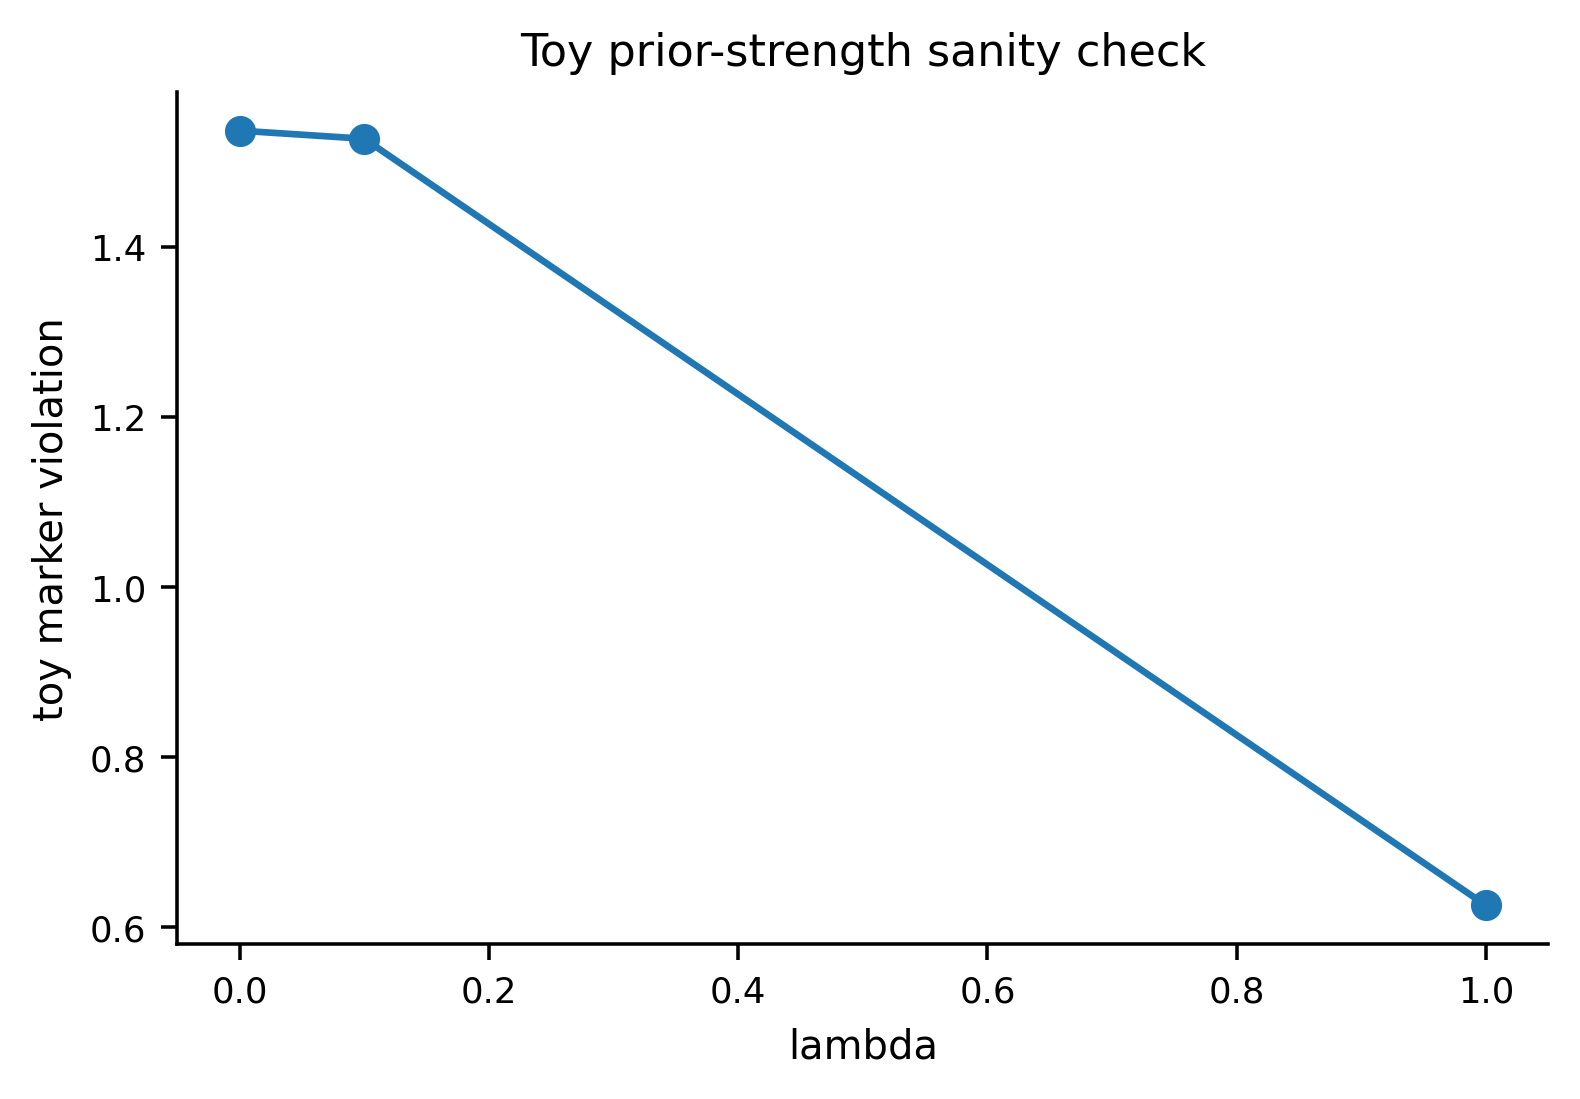

,lambda,monotonicity_violation_sum
0,0.0,1.536948
1,0.1,1.527401
2,1.0,0.625742


In [29]:
# Optional small toy marker monotonicity sanity check.
lambdas = [0, 0.1, 1.0]
marker_rows = []
for lam in lambdas:
    vals = np.linspace(0, 1, 50) + np.random.default_rng(int(lam * 100 + 5)).normal(scale=0.08 / (1 + lam), size=50)
    violations = np.maximum(0, -np.diff(vals)).sum()
    marker_rows.append({"lambda": lam, "monotonicity_violation_sum": float(violations)})
marker_table = pd.DataFrame(marker_rows)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(marker_table["lambda"], marker_table["monotonicity_violation_sum"], marker="o")
ax.set_xlabel("lambda")
ax.set_ylabel("toy marker violation")
ax.set_title("Toy prior-strength sanity check")
save_figure(fig, "figA_4_1_prior_strength_sanity_check.png")
display_saved_figure("figA_4_1_prior_strength_sanity_check.png")
marker_table

## Final Paper-Ready Figure Package and QA

This final section writes the standalone `figures/ch04/new3/` package, records the source tables/json used, and checks that every required PNG/PDF/SVG exists. The claim boundary remains narrow: sampling-depth proxy, equal-depth mass convention, mass-convention sensitivity of growth readouts, and a separate synthetic normalized bridge-width demo.

In [30]:
FINAL_FIGURE_CLAIMS = {
    "fig4_11a_raw_observed_counts": "Raw destructive snapshot counts are sampling-depth proxies, not calibrated biological abundance.",
    "fig4_11b_equal_depth_composition": "Equal-depth subsampling changes the mass convention while preserving state-bin composition diagnostics.",
    "fig4_11c_sampling_depth_bootstrap_sensitivity": "Raw-count growth proxies are sensitive to equal-depth bootstrap intervals under the sampling-depth diagnostic.",
    "fig4_11d_wfrfm_raw_minus_equal_growth_heatmap": "WFR-FM growth readout changes under raw-depth minus equal-depth mass convention.",
    "fig4_11e_wfrfm_mass_convention_agreement_summary": "WFR-FM rank agreement is high while signs and calibration remain convention-dependent.",
    "fig4_11f_stochastic_bridge_demo": "Stochastic bridge width is a separate synthetic normalized path-family assumption from EB mass convention.",
}
FINAL_FORMATS = ("png", "pdf", "svg")

source_paths = {
    "table4_6_eb_downsampling_diagnostics.csv": remember_source(
        "table4_6_eb_downsampling_diagnostics.csv",
        resolve_required_artifact("table4_6_eb_downsampling_diagnostics.csv", [OUT_DIR]),
    ),
    "table4_6b_eb_bridge_sampling_diagnostics.csv": remember_source(
        "table4_6b_eb_bridge_sampling_diagnostics.csv",
        resolve_required_artifact("table4_6b_eb_bridge_sampling_diagnostics.csv", [OUT_DIR]),
    ),
    "table4_6c_wfrfm_growth_by_bin_full.csv": remember_source(
        "table4_6c_wfrfm_growth_by_bin_full.csv",
        resolve_required_artifact("table4_6c_wfrfm_growth_by_bin_full.csv", [OUT_DIR]),
    ),
    "table4_6d_wfrfm_sampling_sensitivity_full.csv": remember_source(
        "table4_6d_wfrfm_sampling_sensitivity_full.csv",
        resolve_required_artifact("table4_6d_wfrfm_sampling_sensitivity_full.csv", [OUT_DIR]),
    ),
    "wfrfm_sampling_sensitivity_summary_full.json": remember_source(
        "wfrfm_sampling_sensitivity_summary_full.json",
        resolve_required_artifact("wfrfm_sampling_sensitivity_summary_full.json", [OUT_DIR]),
    ),
    "cache/exp10_stochastic_bridge_manifest.json": remember_source(
        "cache/exp10_stochastic_bridge_manifest.json",
        resolve_required_artifact("exp10_stochastic_bridge_manifest.json", [CACHE_DIR, OUT_DIR / "cache"]),
    ),
}

run_config = {
    "SMOKE_MODE": bool(SMOKE_MODE),
    "TRAINING_STEPS": int(TRAINING_STEPS),
    "BATCH_SIZE": int(BATCH_SIZE),
    "DEFAULT_NFE": int(DEFAULT_NFE),
    "DEVICE": str(DEVICE),
    "final_figure_dir": safe_relpath(FINAL_FIG_DIR),
}
save_json(OUT_DIR / "run_config_04_3_sampling_depth_and_claim_boundaries.json", run_config)

claim_boundary_items = [
    ("raw EB counts treated as sampling-depth proxies", True),
    ("equal-depth described as a mass convention", True),
    ("state bins described as coarse PC-20 diagnostics", True),
    ("raw-count proxies not used as calibrated abundance", True),
    ("WFR-FM growth described as a convention-dependent readout", True),
    ("stochastic bridge demo described as synthetic normalized", True),
    ("stochastic bridge width kept separate from EB growth and mass convention", True),
]
checklist_table = pd.DataFrame([{"item": item, "status": "pass" if ok else "fail"} for item, ok in claim_boundary_items])
save_csv(OUT_DIR / "claim_boundary_checklist.csv", checklist_table)

figure_paths = [FINAL_FIG_DIR / f"{stem}.{ext}" for stem in FINAL_FIGURE_CLAIMS for ext in FINAL_FORMATS]
missing_figures = [path for path in figure_paths if not path.exists()]
empty_figures = [path for path in figure_paths if path.exists() and path.stat().st_size <= 0]
if missing_figures:
    raise FileNotFoundError("Missing required final figures: " + ", ".join(safe_relpath(p) for p in missing_figures))
if empty_figures:
    raise ValueError("Empty required final figures: " + ", ".join(safe_relpath(p) for p in empty_figures))

bad_filename_tokens = ("composite", "combined", "multi_panel", "multipanel", "big_figure", "bigfigure")
bad_output_names = [
    path.name for path in figure_paths
    if any(token in path.stem.lower() for token in bad_filename_tokens)
]
if bad_output_names:
    raise ValueError("Output filename implies a composite figure: " + ", ".join(bad_output_names))

manifest_rows = []
for stem, claim in FINAL_FIGURE_CLAIMS.items():
    for ext in FINAL_FORMATS:
        path = FINAL_FIG_DIR / f"{stem}.{ext}"
        manifest_rows.append({
            "artifact": safe_relpath(path),
            "kind": "figure",
            "figure_stem": stem,
            "format": ext,
            "claim_supported": claim,
            "bytes": int(path.stat().st_size),
            "source_tables_or_json": "; ".join(sorted(FINAL_SOURCE_PATHS.values())),
        })
for source_name, source_path in source_paths.items():
    manifest_rows.append({
        "artifact": safe_relpath(source_path),
        "kind": "source_table_or_json",
        "figure_stem": "",
        "format": Path(source_path).suffix.lstrip("."),
        "claim_supported": "Source checked for the final sampling-depth, mass-convention, or bridge-width figure package.",
        "bytes": int(Path(source_path).stat().st_size),
        "source_tables_or_json": source_name,
    })

readme_path = FINAL_FIG_DIR / "README_final_check.md"
manifest_path = FINAL_FIG_DIR / "final_polish_manifest.csv"
readme_lines = [
    "# Chapter 4 Final Small Figure Package",
    "",
    f"Output directory: `{safe_relpath(FINAL_FIG_DIR)}`",
    "",
    "Claim boundary:",
    "- Raw observed EB counts are sampling-depth proxies, not calibrated biological abundance.",
    "- Equal-depth subsampling changes the mass convention while preserving state-bin composition diagnostics.",
    "- Raw-count growth proxies and WFR-FM growth readouts depend on the input mass convention.",
    "- Stochastic bridge width is a separate synthetic normalized path-family assumption.",
    "",
    "Generated figure stems:",
]
for stem, claim in FINAL_FIGURE_CLAIMS.items():
    readme_lines.append(f"- `{stem}`: {claim}")
readme_lines.extend([
    "",
    "Source tables/json checked:",
])
for name, path in source_paths.items():
    readme_lines.append(f"- `{safe_relpath(path)}`")
readme_lines.extend([
    "",
    "QA checks:",
    "- Required PNG/PDF/SVG files exist and are nonzero.",
    "- Output filenames do not imply a composite figure.",
    "- This README and `final_polish_manifest.csv` were written.",
])
readme_path.write_text("\n".join(readme_lines) + "\n")

manifest_rows.extend([
    {
        "artifact": safe_relpath(readme_path),
        "kind": "readme",
        "figure_stem": "",
        "format": "md",
        "claim_supported": "Final check and claim-boundary summary.",
        "bytes": int(readme_path.stat().st_size),
        "source_tables_or_json": "",
    },
    {
        "artifact": safe_relpath(manifest_path),
        "kind": "manifest",
        "figure_stem": "",
        "format": "csv",
        "claim_supported": "Artifact list with supported claims.",
        "bytes": 0,
        "source_tables_or_json": "",
    },
])
final_polish_manifest = pd.DataFrame(manifest_rows)
save_csv(manifest_path, final_polish_manifest)
final_polish_manifest.loc[final_polish_manifest["artifact"] == safe_relpath(manifest_path), "bytes"] = int(manifest_path.stat().st_size)
save_csv(manifest_path, final_polish_manifest)

if not readme_path.exists() or readme_path.stat().st_size <= 0:
    raise FileNotFoundError(readme_path)
if not manifest_path.exists() or manifest_path.stat().st_size <= 0:
    raise FileNotFoundError(manifest_path)

qa_table = pd.DataFrame({
    "check": [
        "required_png_pdf_svg_exist",
        "required_png_pdf_svg_nonzero",
        "no_composite_output_filename",
        "readme_written",
        "manifest_written",
    ],
    "status": ["pass", "pass", "pass", "pass", "pass"],
})
print("Final figure directory:", safe_relpath(FINAL_FIG_DIR))
print("Final figure stems:", ", ".join(FINAL_FIGURE_CLAIMS))
print("Source files used:", ", ".join(sorted(FINAL_SOURCE_PATHS.values())))
display(qa_table)
display(final_polish_manifest)

Final figure directory: figures/ch04/new3
Final figure stems: fig4_11a_raw_observed_counts, fig4_11b_equal_depth_composition, fig4_11c_sampling_depth_bootstrap_sensitivity, fig4_11d_wfrfm_raw_minus_equal_growth_heatmap, fig4_11e_wfrfm_mass_convention_agreement_summary, fig4_11f_stochastic_bridge_demo
Source files used: outputs/ch04/cache/exp10_stochastic_bridge_manifest.json, outputs/ch04/table4_6_eb_downsampling_diagnostics.csv, outputs/ch04/table4_6b_eb_bridge_sampling_diagnostics.csv, outputs/ch04/table4_6c_wfrfm_growth_by_bin_full.csv, outputs/ch04/table4_6d_wfrfm_sampling_sensitivity_full.csv, outputs/ch04/wfrfm_sampling_sensitivity_summary_full.json


,check,status
0,required_png_pdf_svg_exist,pass
1,required_png_pdf_svg_nonzero,pass
2,no_composite_output_filename,pass
3,readme_written,pass
4,manifest_written,pass


,artifact,kind,figure_stem,format,claim_supported,bytes,source_tables_or_json
0,figures/ch04/new3/fig4_11a_raw_observed_counts...,figure,fig4_11a_raw_observed_counts,png,Raw destructive snapshot counts are sampling-d...,124083,outputs/ch04/cache/exp10_stochastic_bridge_man...
1,figures/ch04/new3/fig4_11a_raw_observed_counts...,figure,fig4_11a_raw_observed_counts,pdf,Raw destructive snapshot counts are sampling-d...,12365,outputs/ch04/cache/exp10_stochastic_bridge_man...
2,figures/ch04/new3/fig4_11a_raw_observed_counts...,figure,fig4_11a_raw_observed_counts,svg,Raw destructive snapshot counts are sampling-d...,17560,outputs/ch04/cache/exp10_stochastic_bridge_man...
3,figures/ch04/new3/fig4_11b_equal_depth_composi...,figure,fig4_11b_equal_depth_composition,png,Equal-depth subsampling changes the mass conve...,95098,outputs/ch04/cache/exp10_stochastic_bridge_man...
4,figures/ch04/new3/fig4_11b_equal_depth_composi...,figure,fig4_11b_equal_depth_composition,pdf,Equal-depth subsampling changes the mass conve...,10948,outputs/ch04/cache/exp10_stochastic_bridge_man...
5,figures/ch04/new3/fig4_11b_equal_depth_composi...,figure,fig4_11b_equal_depth_composition,svg,Equal-depth subsampling changes the mass conve...,16242,outputs/ch04/cache/exp10_stochastic_bridge_man...
6,figures/ch04/new3/fig4_11c_sampling_depth_boot...,figure,fig4_11c_sampling_depth_bootstrap_sensitivity,png,Raw-count growth proxies are sensitive to equa...,216478,outputs/ch04/cache/exp10_stochastic_bridge_man...
7,figures/ch04/new3/fig4_11c_sampling_depth_boot...,figure,fig4_11c_sampling_depth_bootstrap_sensitivity,pdf,Raw-count growth proxies are sensitive to equa...,16430,outputs/ch04/cache/exp10_stochastic_bridge_man...
8,figures/ch04/new3/fig4_11c_sampling_depth_boot...,figure,fig4_11c_sampling_depth_bootstrap_sensitivity,svg,Raw-count growth proxies are sensitive to equa...,36171,outputs/ch04/cache/exp10_stochastic_bridge_man...
9,figures/ch04/new3/fig4_11d_wfrfm_raw_minus_equ...,figure,fig4_11d_wfrfm_raw_minus_equal_growth_heatmap,png,WFR-FM growth readout changes under raw-depth ...,201724,outputs/ch04/cache/exp10_stochastic_bridge_man...
